# **1.1 Postprocessing after training**

This script serves as the main evaluation script to evaluate the geological plausibility **and** diversity of the synthetic samples generated by the GAN model. The script starts with defining the paths to all the training runs, after which the Postprocessing class is initialized for each run. The postprocessing class used global and local evaluation metrics to evaluate the geological plausibility & sample diversity of the synthetic samples with the following functions:
- **Global metrics:**
    - **facies volume percentage:** Evaluates the total proportion of each facies across the entire synthetic dataset of a unique run.
    - **Macro - connectivity and pattern analysis:** The Macro-connectivity measures the absolute sizes of connected 3D bodies (blobs) anywhere in the grid, aggregated across all evaluated samples. Then the  pattern analysis extracts 3x3x3 patterns across the grids to see if the GAN learned the right geological shapes. While the window is small, it sweeps the whole grid and aggregates counts globally. 
    - **3D Spatial Delentropy:** Computes the structural complexity of an entire 3D volume by analyzing the overall distribution of spatial gradients.
    - **Multi-Scale Sliced Wasserstein Distance (MS-SWD):** Evaluates the overall distributional distance between entire 3D volumes to see if the GAN manifold matches the Flumy manifold.
    
- **Local metrics:**
    - **Normalized Spatial Entropy:** Highly local (often called "ensemble cell-wise" metric). It calculates the probability of a facies occurring at a specific pixel (e.g., X=10,Y=15) across your 100+ realizations.
    - **Local Delentropy Map:** Generates a 2D heatmap by sliding a window over the grid. Because it maps the complexity back to specific spatial coordinates, it is a local diagnostic tool.
    - **JSD & Slice Metrics:** Because your script calculates Jensen-Shannon Divergence using axis=0 across the stacked samples (p_data vs p_gan), it is actually computing the pixel-by-pixel local distance between the datasets, which is then averaged to give a slice-wise summary.

In [1]:
# Apply Autoreload so the script automatically detects changes in .py helper scripts

%load_ext autoreload
%autoreload 2

In [2]:
# IMport nescessary functions and helper functions

import os
import sys
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from gan_pipeline.core import custom_plots as custom_plots
from postprocessing import PostProcessing
custom_plots.apply_custom_plotting_flavor()

In [16]:
# 1. Define the root project path
project_root = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM")

# 2. Define the primary sub-directories
base_datasets = project_root / "datasets" / "testing"
base_outputs = project_root / "outputs" / "post_training" / "20000_training_samples"
base_outputs_2 = project_root / "outputs" / "post_training" / "10000_training_samples"
base_plots = project_root / "plots" / "post_training_plots"

# --- REAL DATA ---
#data_dir_1 = base_datasets / "setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100" / "samples" / "facies" / "*.npy"
data_dir_2 = base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_6_isbx_100" / "samples" / "facies" / "*.npy"
#data_dir_3 = base_datasets / "setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120" / "samples" / "facies" / "*.npy"

output_dir_fac1 = base_datasets / "setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100"
output_dir_fac2 = base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80"
output_dir_fac3 = base_datasets / "setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120"

# --- GAN DATA ---
gan_data_dir_01 = base_outputs / "25_epochs_3_classes_cgan_num_iter_1_no_penalty_lr_gen_1e3_disc_3e3_doubleconv_on_setting_2" / "realizations" / "*.npy"
gan_data_dir_02 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_off_no_penalty_setting_2" / "realizations" / "*.npy"
# gan_data_dir_03 = base_outputs / "25_epochs_3_classes_cgan_num_iter_1_penalty_every_iter_lr_gen_1e3_disc_3e3_double_conv_on_setting_2" / "realizations" / "*.npy"
# gan_data_dir_04 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_off_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
# gan_data_dir_05 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_1e2_doubleconv_on_penalty_every_1_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_06 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_1_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_07 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_no_penalty_setting_2" / "realizations" / "*.npy"
gan_data_dir_08 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_8_1 = base_outputs / "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_09 = base_outputs / "25_epochs_3_classes_cgan_dynamic_lr_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_10 = base_outputs_2 / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_11 = base_outputs / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_32_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_12 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_disc_iter_2_setting_2" / "realizations" / "*.npy"
gan_data_dir_13 = base_outputs / "25_epochs_3_classes_cgan_lr_1e3_gen_1e2_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"

# Model trained on all settings
gan_data_dir_all = base_outputs / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings" / "realizations" / "*.npy"

# --- PLOT OUTPUTS TO ---
output_dir_gan_01 = base_plots / "25_epochs_3_classes_cgan_num_iter_1_no_penalty_lr_gen_1e3_disc_3e3_doubleconv_on_setting_2"
output_dir_gan_02 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_off_no_penalty_setting_2"
# output_dir_gan_03 = base_plots / "25_epochs_3_classes_cgan_num_iter_1_penalty_every_iter_lr_gen_1e3_disc_3e3_double_conv_on_setting_2"
# output_dir_gan_04 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_off_penalty_every_16_iter_setting_2"
# output_dir_gan_05 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_1e2_doubleconv_on_penalty_every_1_iter_setting_2"
output_dir_gan_06 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_1_iter_setting_2"
output_dir_gan_07 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_no_penalty_setting_2"
output_dir_gan_08 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_8_1 = base_plots / "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_09 =  base_plots / "25_epochs_3_classes_cgan_dynamic_lr_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_10 =  base_plots / "25_epochs_10000_samples_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_11 = base_plots / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_32_iter_setting_2"
output_dir_gan_12 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_disc_iter_2_setting_2"
output_dir_gan_13 = base_plots / "25_epochs_3_classes_cgan_lr_1e3_gen_1e2_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" 

output_dir_gan_all = base_plots / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings" 

# --- POST PROCESSING / VALIDATORS ---
run_configs = [
    #("Run 2", "Run 1: FluvGAN", output_dir_gan_02, gan_data_dir_02),
    #("Run 1", "Run 2: Run 1 + double conv", output_dir_gan_01, gan_data_dir_01),
    # ("Run 3", output_dir_gan_03, gan_data_dir_03),
    # ("Run 4", output_dir_gan_04, gan_data_dir_04),
    #("Run 5", output_dir_gan_05, gan_data_dir_05),
    #("Run 7", "Run 3: Run 2 + double resblock", output_dir_gan_07, gan_data_dir_07),
    #("Run 11", "Run 4: Run 3 + penalty 1", output_dir_gan_11, gan_data_dir_11),
    ("Run 8", "Run 5: Run 3 + penalty 2", output_dir_gan_08, gan_data_dir_08),
    #("Run 6", "Run 6: Run 3 + penalty 3", output_dir_gan_06, gan_data_dir_06),
    #("Run 10", "Run 7: Run 5 less samples", output_dir_gan_10, gan_data_dir_10),
    #("Run 8.1", output_dir_gan_8_1, gan_data_dir_8_1),
    #("Run 9", output_dir_gan_09, gan_data_dir_09),
    #("Run 12", "Run 8: Run 5 less iterations discriminator", output_dir_gan_12, gan_data_dir_12),
    #("Run 13", output_dir_gan_13, gan_data_dir_13),
    ("Run All", "Run all settings enables", output_dir_gan_all, gan_data_dir_all)
]

validators = []

# Loop through the configurations
for gan_name, gan_description, out_dir, gan_path in run_configs:
    
    # 1. Create directories if they don't exist
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize the validator
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=data_dir_2,
        gan_path=gan_path
    )
    
    # 2. Load the samples
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    validators.append(validator)

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 8 samples (limit: 100)...
Loaded 100 Run 8 samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run All samples (limit: 100)...
Loaded 100 Run All samples into memory.


**GAN Runs hyperparameter descriptions**

| Run Number    | Epochs    | num_iter_disc | lr generator  | lr disc       | batch size| setting   |num samples| disc penalty (iter)   | double conv   | double resblock   | nr classes| Best JSD          |
| :---          | :---      | :---          | :---          | :---          | :---      | :---      | :---      | :---                  | :---          | :---              |  :---     | :---              |
| 1             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         no            |       on      |       off         |     3     |  0.1161 ± 0.0243  |
| 2             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         no            |       off     |       off         |     3     |  0.0718 ± 0.0157  |
| 3             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         1             |       on      |       off         |     3     |  0.0449 ± 0.0083  |
| 4             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         16            |       off     |       off         |     3     |  0.0869 ± 0.0202  |
| 5             |     25    |     1         |     1e3       |     1e2       |     64    |     2     |   20000   |         1             |       on      |       off         |     3     |  0.0393 ± 0.0108  |
| 6             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         1             |       on      |       on          |     3     |  0.0202 ± 0.0038  |
| 7             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         no            |       on      |       on          |     3     |  0.0458 ± 0.0076  |
| 8             |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         16            |       on      |       on          |     3     |  0.0155 ± 0.0067  |
| 8.1           |     100   |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         16            |       on      |       on          |     3     |  0.0146 ± 0.0082  |
| 9             |     25    |     1         |1e3 -> dynamic |3e3 -> dynamic |     64    |     2     |   20000   |         16            |       on      |       on          |     3     |  0.0511 ± 0.0147  |
| 10            |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   10000   |         16            |       on      |       on          |     3     |  0.1190 ± 0.0324  |
| 11            |     25    |     1         |     1e3       |     3e3       |     64    |     2     |   20000   |         32            |       on      |       on          |     3     |   0.0612 ± 0.0314 |
| 12            |     25    |     2         |     1e3       |     3e3       |     64    |     2     |   20000   |         16            |       on      |       on          |     3     |   0.0278 ± 0.0045 |
| 13            |     25    |     1         |     1e3       |     1e2       |     64    |     2     |   20000   |         16            |       on      |       on          |     3     |    |

Experiments to perform:
- Over regularization: Push disc penalty to 32 to find the ceiling where too much penalty causes the gradients to vanish and training to collapse. If 32 improves JSD, keep climbing. If it gets worse, you know 16 is the local minimum.
- Critic dominance: In many advanced GAN setups (like WGAN-GP), updating the discriminator 2 to 5 times per generator update provides a much cleaner gradient signal. Combined with your high penalty (16), this could stabilize the manifold mapping even further.
- Aggressive Critic: Test agressive critic (1e2) with double conv and double resblocks on since the agressive critic improved the network JSD.


Starting MS-SWD plotting progression...

Processing run: Run 8


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_31924\2754222477.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10') # Good for up to 10 distinct colors


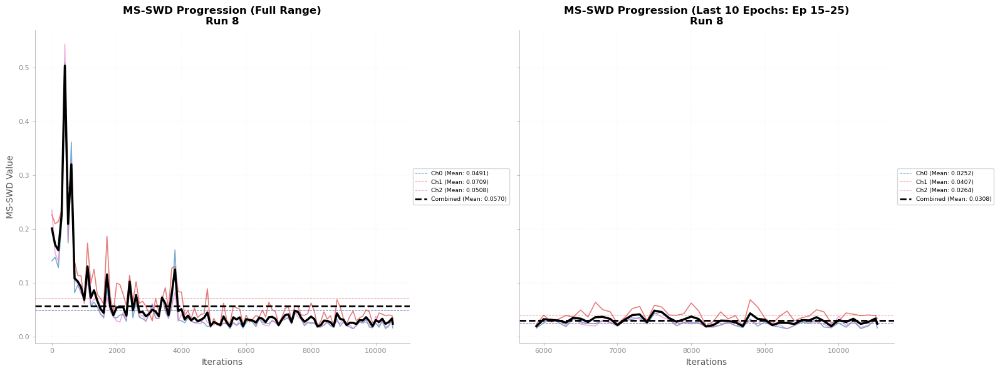

Successfully saved plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\ms_swd_progression_run_8.png

Processing run: Run All


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_31924\2754222477.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10') # Good for up to 10 distinct colors


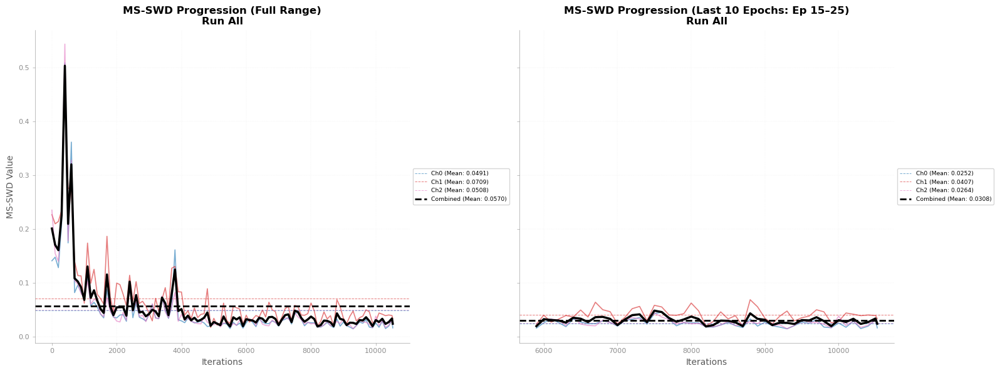

Successfully saved plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\ms_swd_progression_run_all.png


In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

print("\nStarting MS-SWD plotting progression...")

# UPDATE THIS LINE to point to your actual .csv file, not the .pt file!
history_filename = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv"

for gan_name, gan_description, out_dir, gan_path in run_configs:
    gan_path = Path(gan_path)
    run_dir = gan_path.parent.parent
    csv_path = Path(history_filename)
    
    print(f"\nProcessing run: {gan_name}")
    
    if not csv_path.exists():
        print(f"⚠️ Warning: History file not found at {csv_path}. Skipping this run.")
        continue
        
    df = pd.read_csv(csv_path)
    df.columns = [col.strip() for col in df.columns] 
    
    epoch_col = 'epochs' if 'epochs' in df.columns else ('epoch' if 'epoch' in df.columns else None)
    
    if not epoch_col or 'iteration' not in df.columns:
        print(f"⚠️ Warning: Missing epoch/iteration columns. Skipping.")
        continue
        
    # 1. Dynamically find all MS-SWD channels
    channels = [col for col in df.columns if col.startswith('MS-SWD_Ch')]
    
    if not channels:
        print(f"⚠️ Warning: No MS-SWD channels found in CSV. Skipping.")
        continue
        
    df_metrics = df.dropna(subset=channels).copy()
    
    if df_metrics.empty:
        print(f"⚠️ Warning: No valid metric calculations found. Skipping.")
        continue
        
    # Calculate the combined channel mean across all 9 channels
    df_metrics['MS-SWD_Combined'] = df_metrics[channels].mean(axis=1)
    all_metrics = channels + ['MS-SWD_Combined']
    
    max_epoch = df_metrics[epoch_col].max()
    df_last_10 = df_metrics[df_metrics[epoch_col] >= (max_epoch - 10)].copy()
    
    # 2. Dynamically generate colors for any number of channels
    cmap = cm.get_cmap('tab10') # Good for up to 10 distinct colors
    colors = {ch: cmap(i/len(channels)) for i, ch in enumerate(channels)}
    # Assign a distinct color and line thickness for the combined metric
    colors['MS-SWD_Combined'] = 'black' 
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # --- SUBPLOT 1: FULL RANGE ---
    ax1 = axes[0]
    for col in all_metrics:
        label_short = col.replace('MS-SWD_', '')
        mean_val = df_metrics[col].mean()
        color = colors[col]
        lw = 2.5 if col == 'MS-SWD_Combined' else 1.2
        alpha = 1.0 if col == 'MS-SWD_Combined' else 0.6
        
        ax1.plot(df_metrics['iteration'], df_metrics[col], color=color, linewidth=lw, alpha=alpha)
        ax1.axhline(mean_val, color=color, linestyle='--', linewidth=lw-0.5, alpha=alpha,
                    label=f"{label_short} (Mean: {mean_val:.4f})")
        
    ax1.set_title(f"MS-SWD Progression (Full Range)\n{gan_name}", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Iterations", fontsize=10)
    ax1.set_ylabel("MS-SWD Value", fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    # Move legend outside if there are many channels
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    
    # --- SUBPLOT 2: LAST 10 EPOCHS ---
    ax2 = axes[1]
    if not df_last_10.empty:
        for col in all_metrics:
            label_short = col.replace('MS-SWD_', '')
            mean_val_l10 = df_last_10[col].mean()
            color = colors[col]
            lw = 2.5 if col == 'MS-SWD_Combined' else 1.2
            alpha = 1.0 if col == 'MS-SWD_Combined' else 0.6
            
            ax2.plot(df_last_10['iteration'], df_last_10[col], color=color, linewidth=lw, alpha=alpha)
            ax2.axhline(mean_val_l10, color=color, linestyle='--', linewidth=lw-0.5, alpha=alpha,
                        label=f"{label_short} (Mean: {mean_val_l10:.4f})")
            
        ax2.set_title(f"MS-SWD Progression (Last 10 Epochs: Ep {int(max_epoch-10)}–{int(max_epoch)})\n{gan_name}", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Iterations", fontsize=10)
        ax2.grid(True, linestyle=':', alpha=0.6)
        ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    else:
        ax2.text(0.5, 0.5, "Not enough data for\nlast 10 epochs evaluation", 
                 ha='center', va='center', transform=ax2.transAxes, color='gray')
        ax2.set_title("MS-SWD Progression (Last 10 Epochs)", fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    
    os.makedirs(out_dir, exist_ok=True)
    sanitized_name = gan_name.lower().replace(":", "").replace(" ", "_")
    plot_path = Path(out_dir) / f"ms_swd_progression_{sanitized_name}.png"
    
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Successfully saved plot to: {plot_path}")

## **1.1 2D Visualizations**

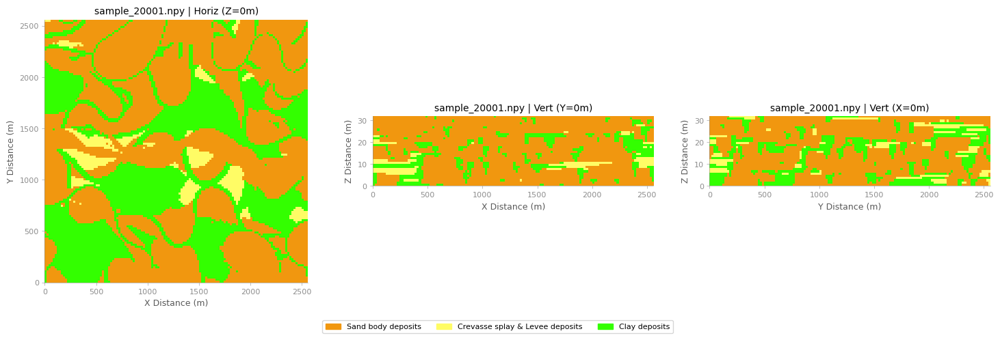

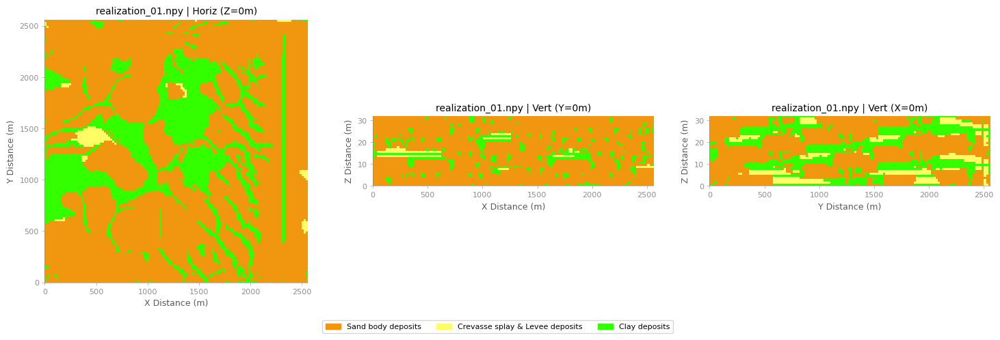

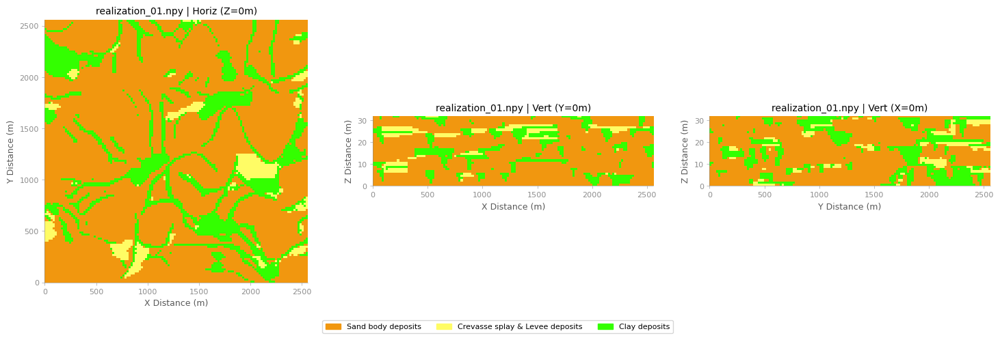

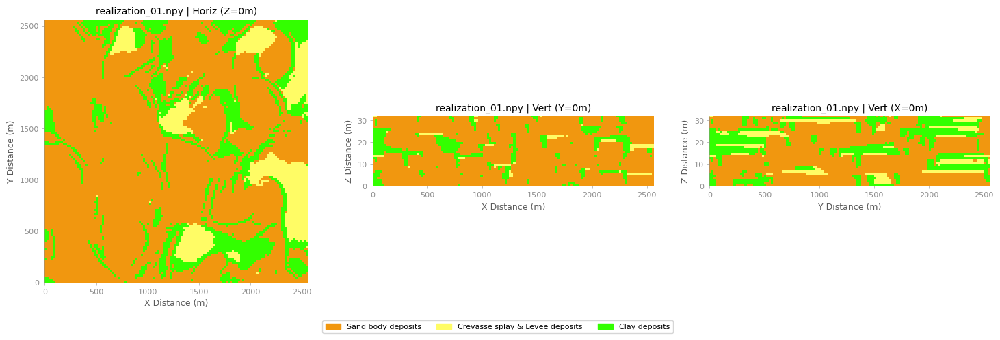

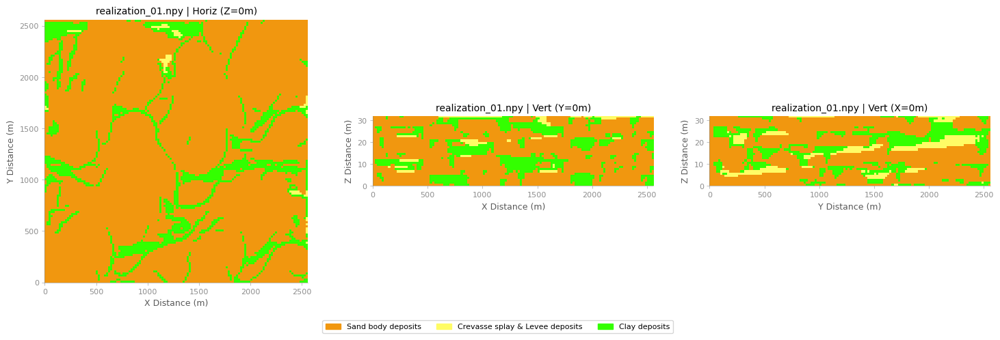

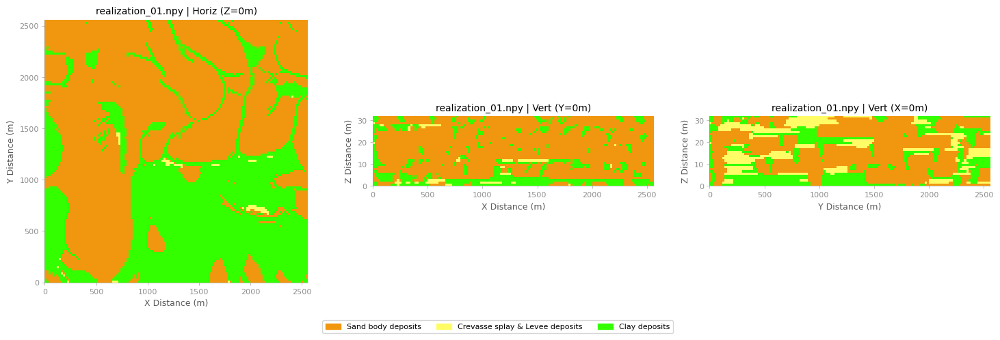

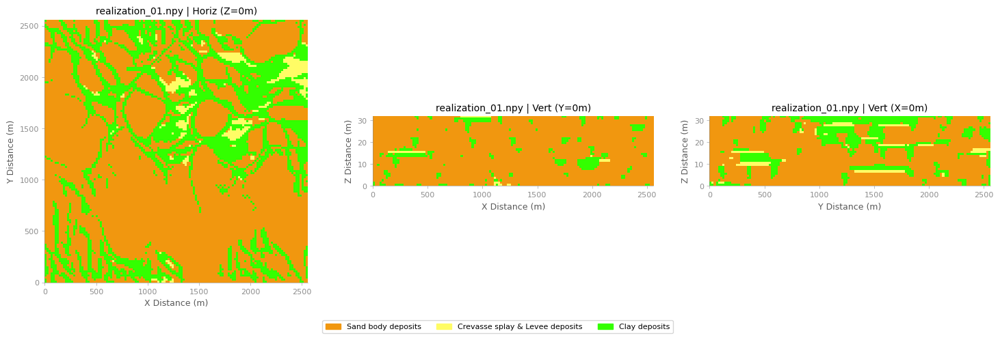

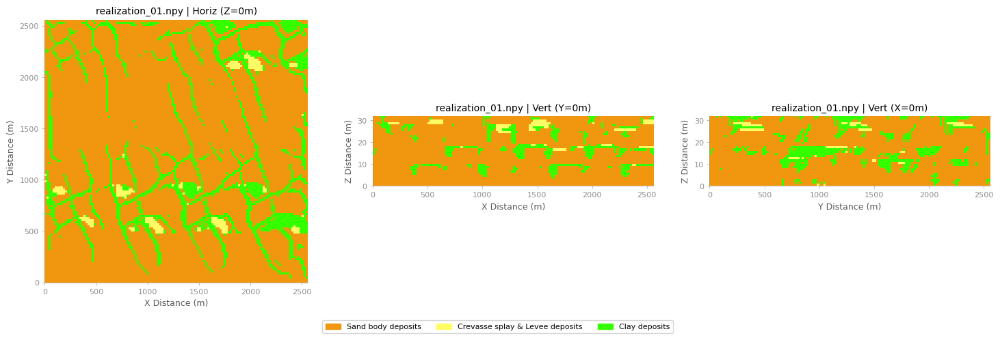

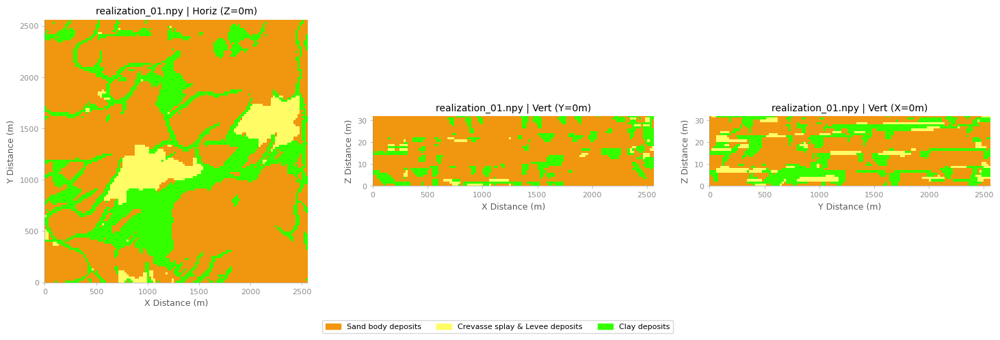

In [4]:
for i, validator in enumerate(validators):
    if i == 0:
        validator.plot_2d_slices(data_source='flumy',num_slices=1)
        validator.plot_2d_slices(num_slices=1)
    else:
        validator.plot_2d_slices(num_slices=1)

## **1.2 3D Visualizations**


--- Generating 3D PyVista Plot (setting 2 | Mode: COMBINED) ---


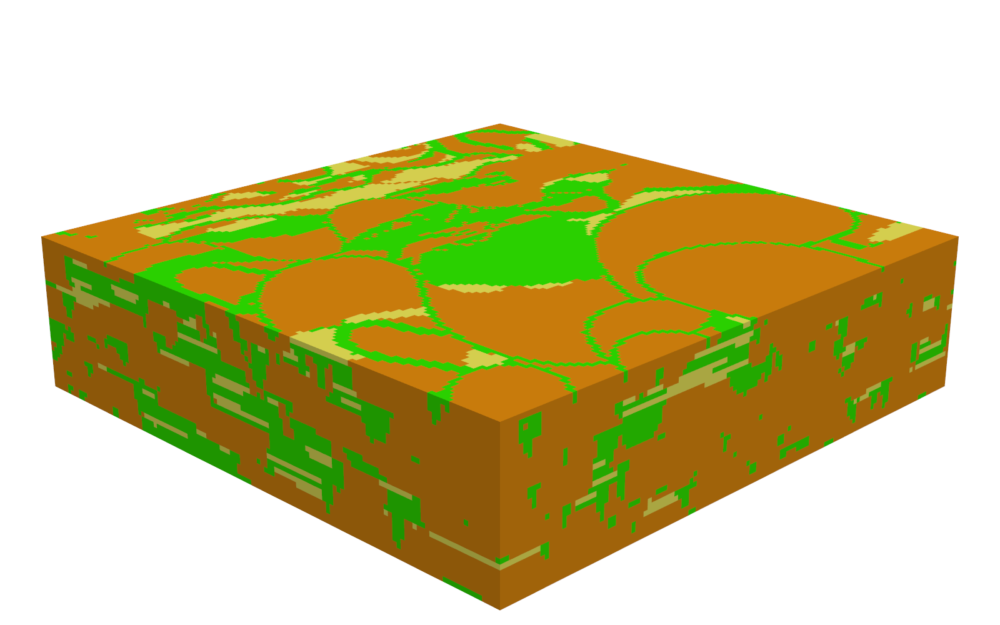

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_off_no_penalty_setting_2\3d_plot_flumy_sample_1combined.png

--- Generating 3D PyVista Entropy Map (setting 2) ---
[setting 2] Calculated Mean Voxel-Wise Entropy: 0.6922


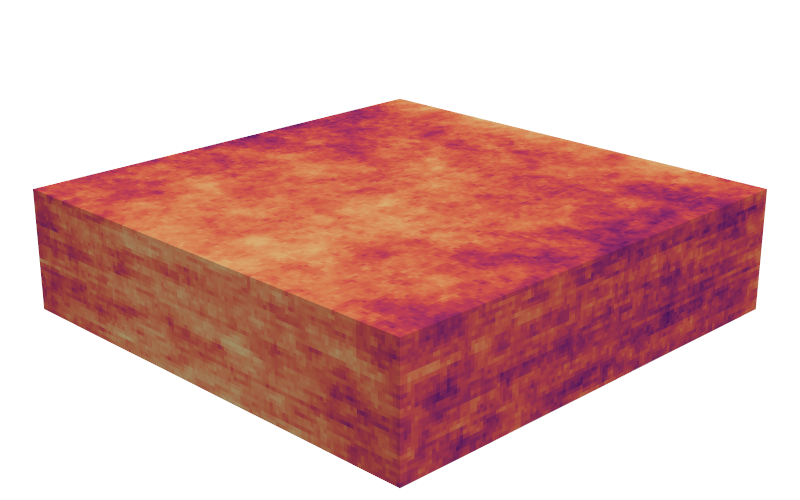


--- Generating 3D PyVista Plot (Run 2 | Mode: COMBINED) ---


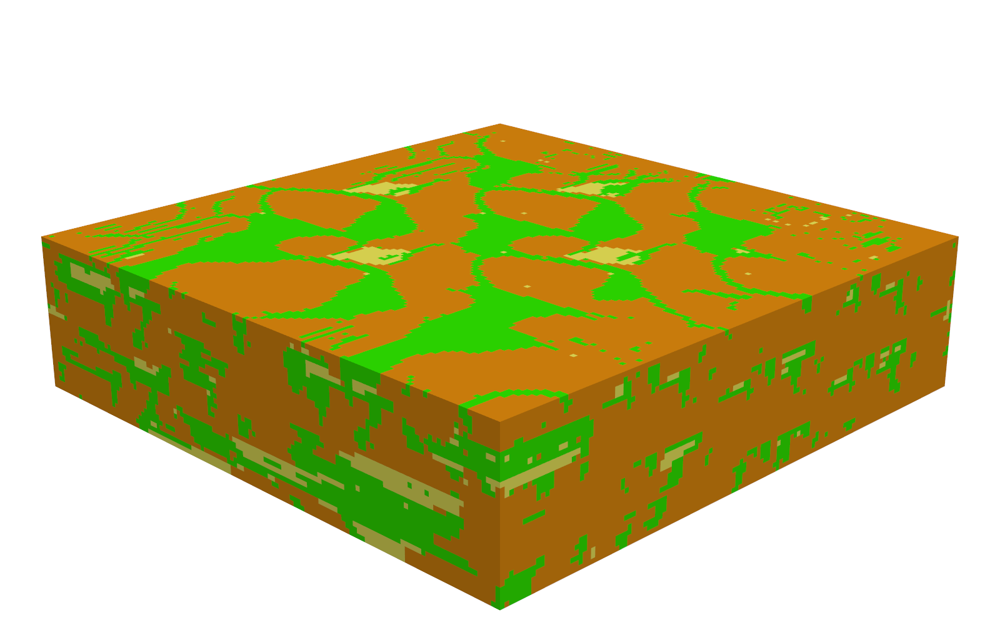

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_off_no_penalty_setting_2\3d_plot_gan_sample_48combined.png

--- Generating 3D PyVista Entropy Map (Run 2) ---
[Run 2] Calculated Mean Voxel-Wise Entropy: 0.5146


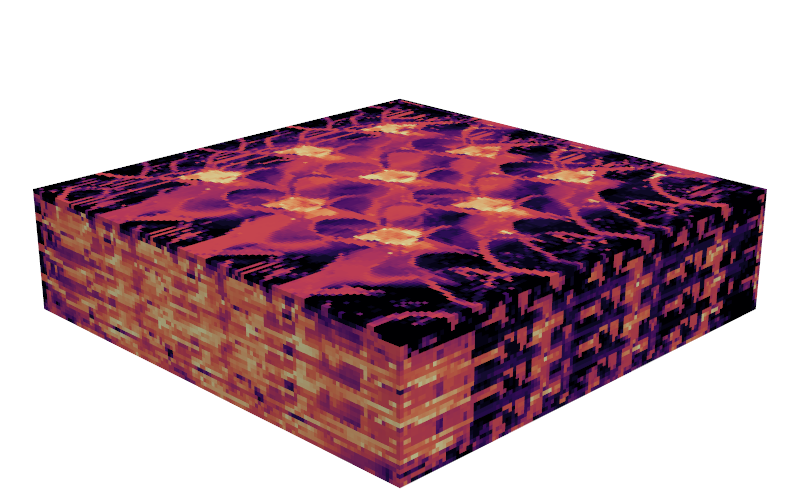


--- Generating 3D PyVista Plot (Run 1 | Mode: COMBINED) ---


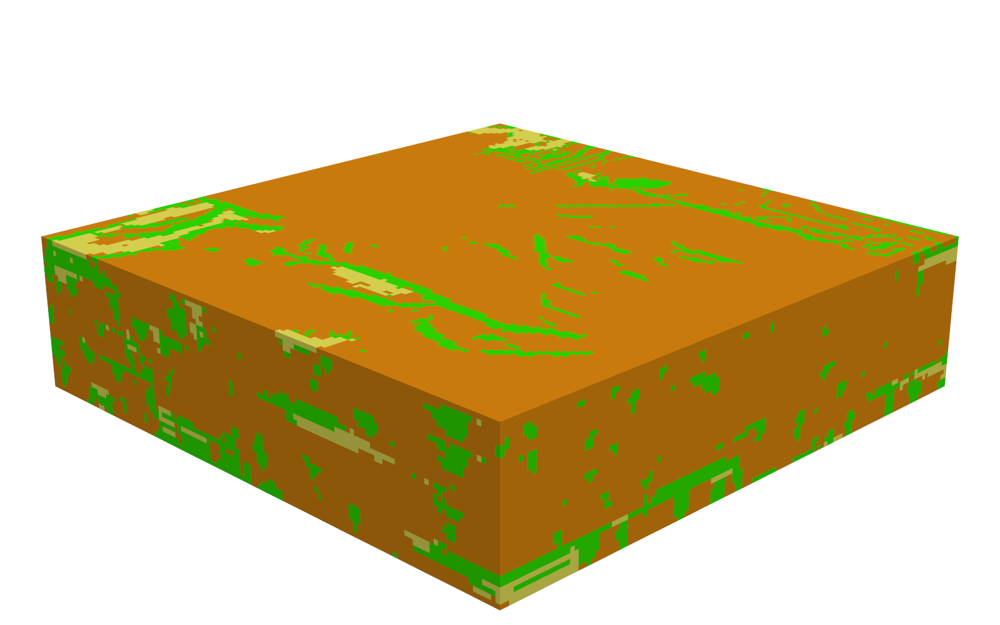

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_num_iter_1_no_penalty_lr_gen_1e3_disc_3e3_doubleconv_on_setting_2\3d_plot_gan_sample_27combined.png

--- Generating 3D PyVista Entropy Map (Run 1) ---
[Run 1] Calculated Mean Voxel-Wise Entropy: 0.4304


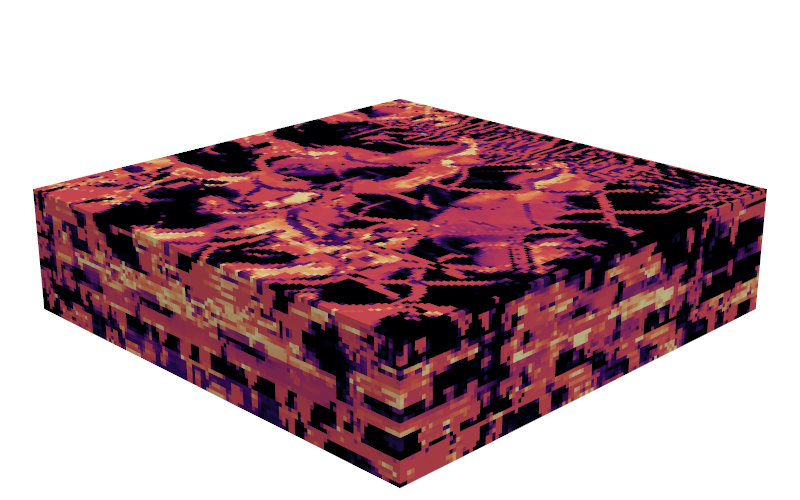


--- Generating 3D PyVista Plot (Run 7 | Mode: COMBINED) ---


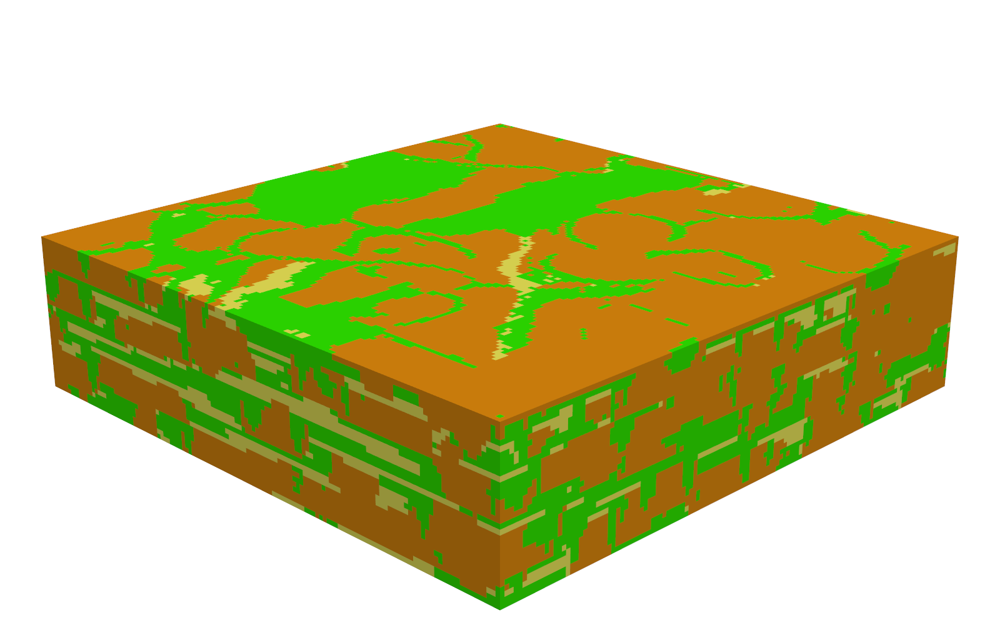

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_no_penalty_setting_2\3d_plot_gan_sample_10combined.png

--- Generating 3D PyVista Entropy Map (Run 7) ---
[Run 7] Calculated Mean Voxel-Wise Entropy: 0.6374


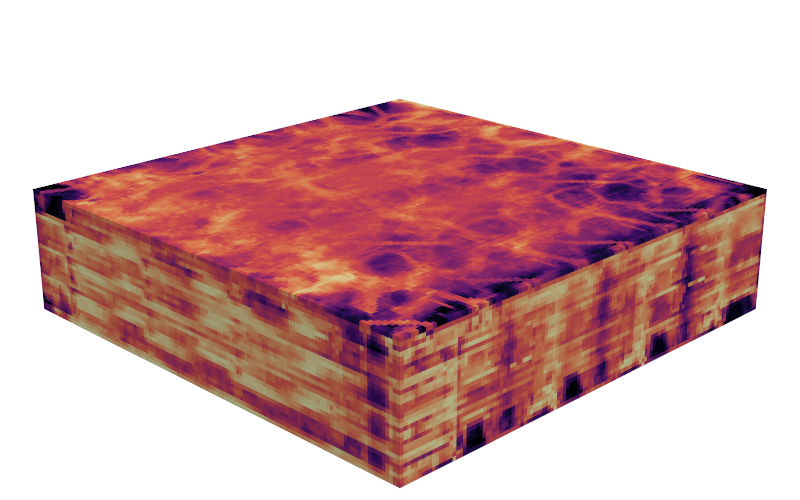


--- Generating 3D PyVista Plot (Run 11 | Mode: COMBINED) ---


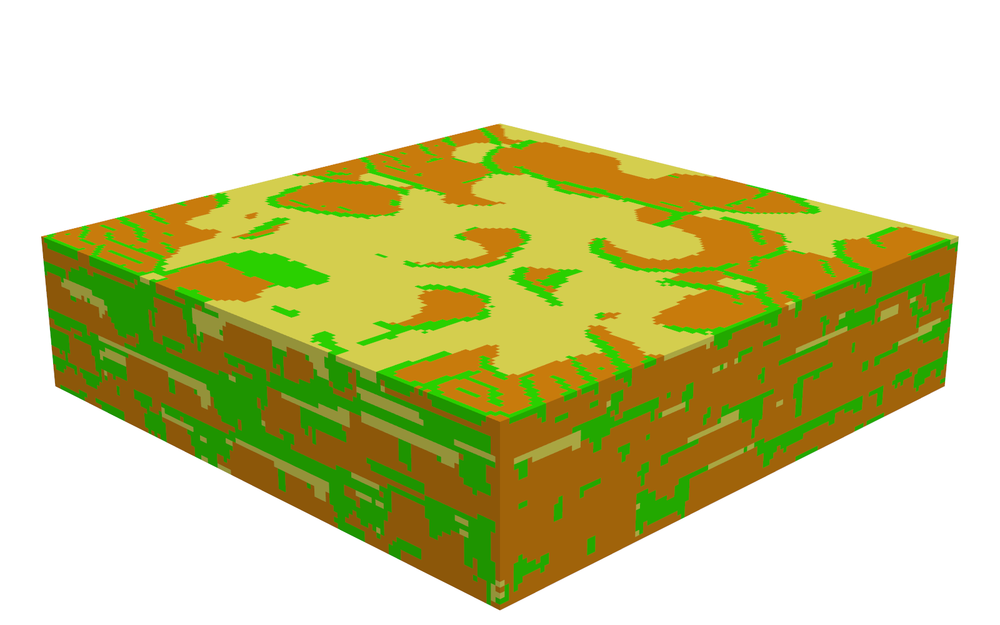

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_32_iter_setting_2\3d_plot_gan_sample_49combined.png

--- Generating 3D PyVista Entropy Map (Run 11) ---
[Run 11] Calculated Mean Voxel-Wise Entropy: 0.6292


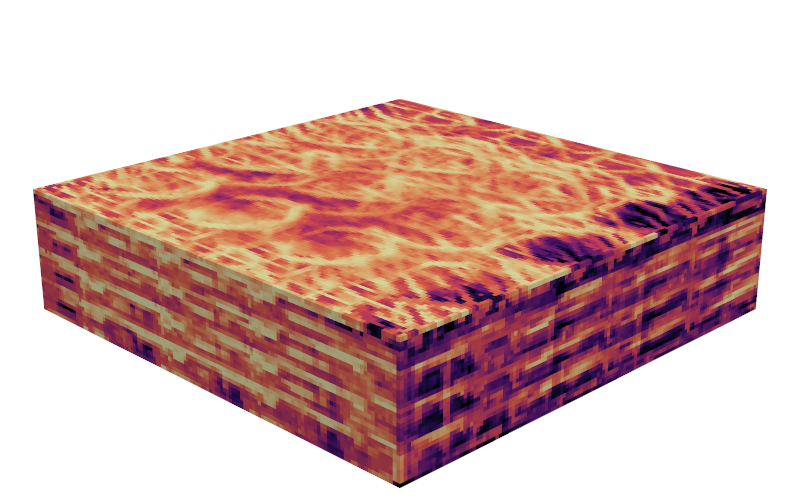


--- Generating 3D PyVista Plot (Run 8 | Mode: COMBINED) ---


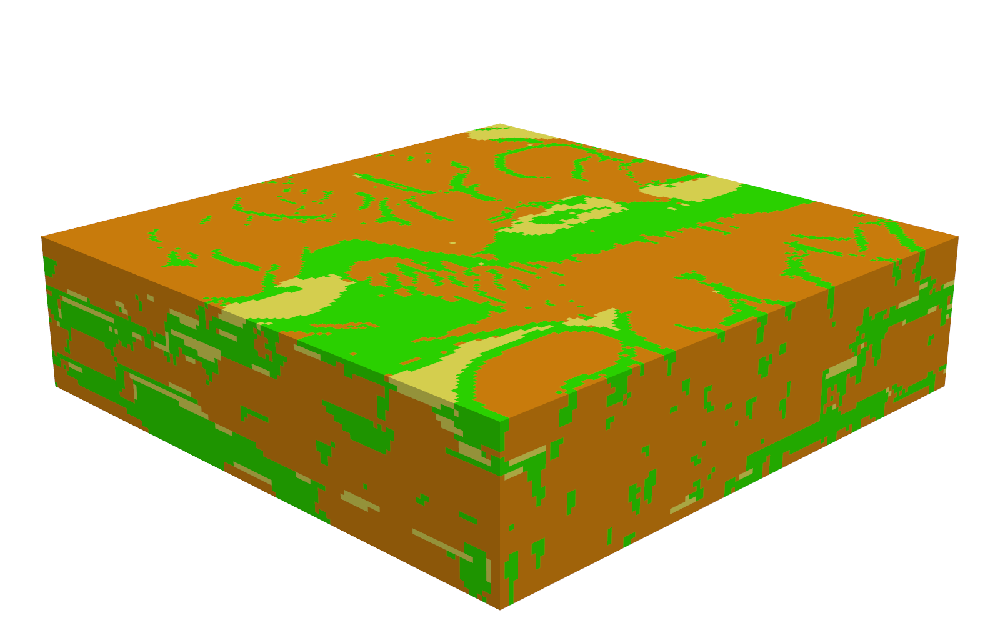

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\3d_plot_gan_sample_96combined.png

--- Generating 3D PyVista Entropy Map (Run 8) ---
[Run 8] Calculated Mean Voxel-Wise Entropy: 0.7037


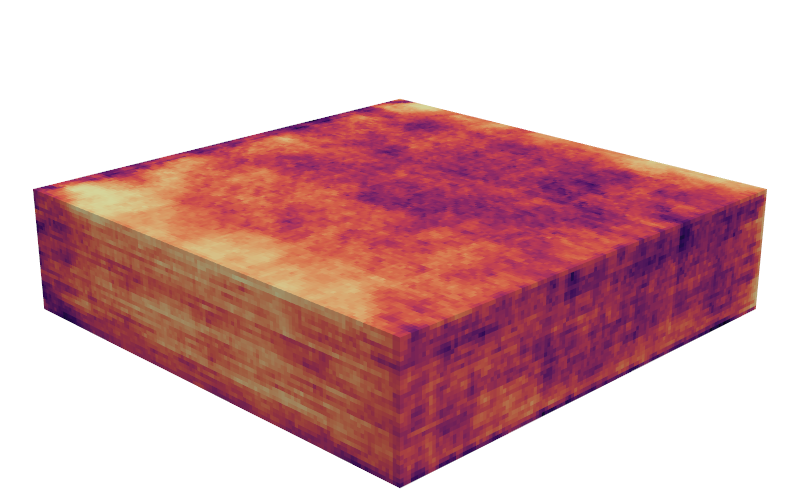


--- Generating 3D PyVista Plot (Run 6 | Mode: COMBINED) ---


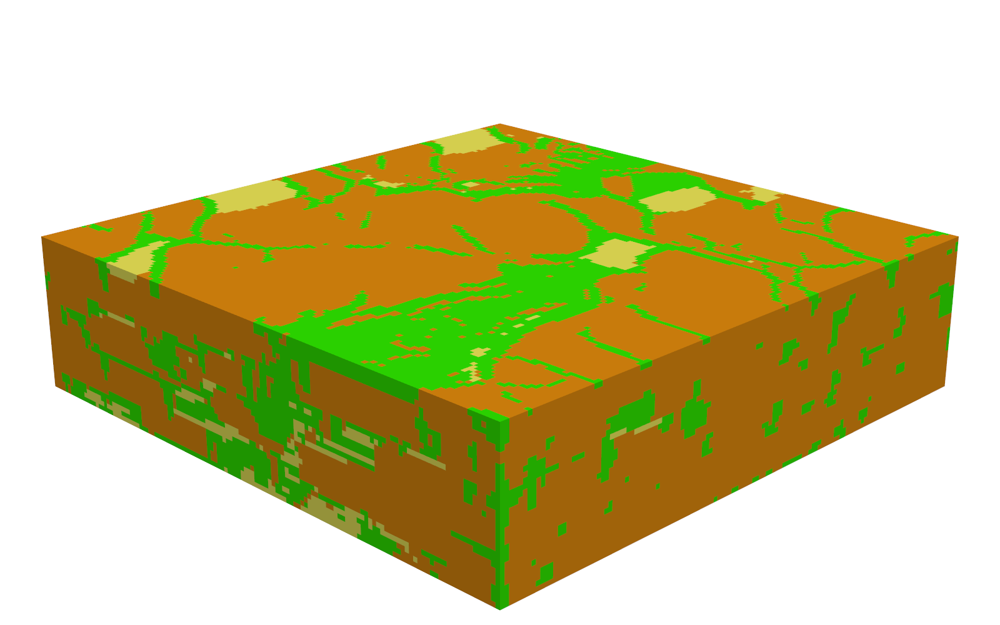

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_1_iter_setting_2\3d_plot_gan_sample_82combined.png

--- Generating 3D PyVista Entropy Map (Run 6) ---
[Run 6] Calculated Mean Voxel-Wise Entropy: 0.6141


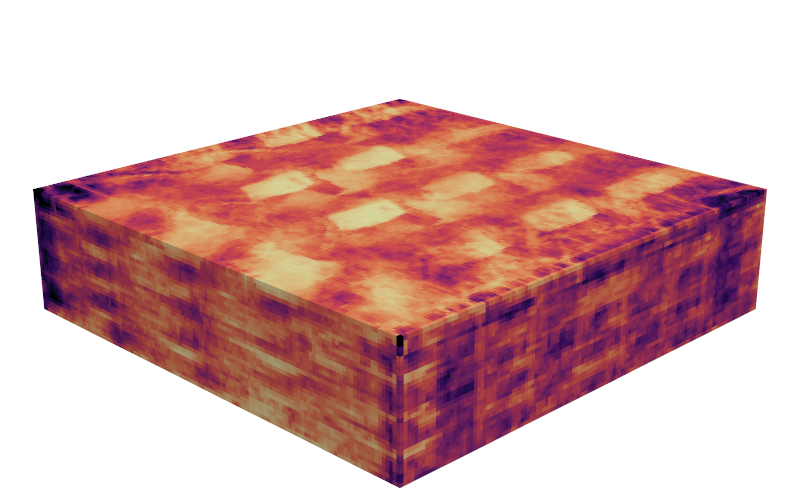


--- Generating 3D PyVista Plot (Run 10 | Mode: COMBINED) ---


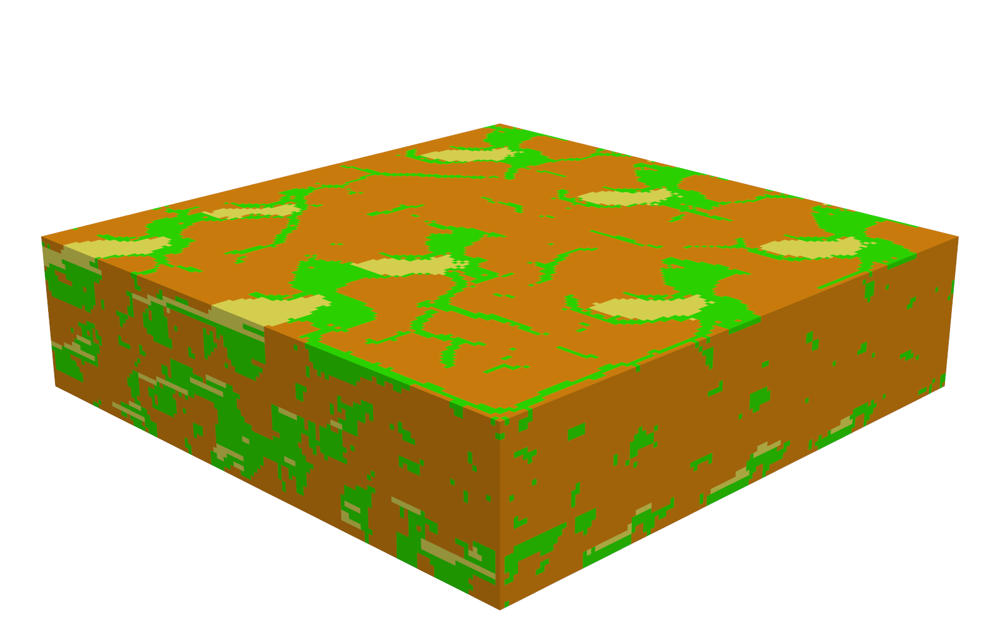

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_10000_samples_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\3d_plot_gan_sample_24combined.png

--- Generating 3D PyVista Entropy Map (Run 10) ---
[Run 10] Calculated Mean Voxel-Wise Entropy: 0.3926


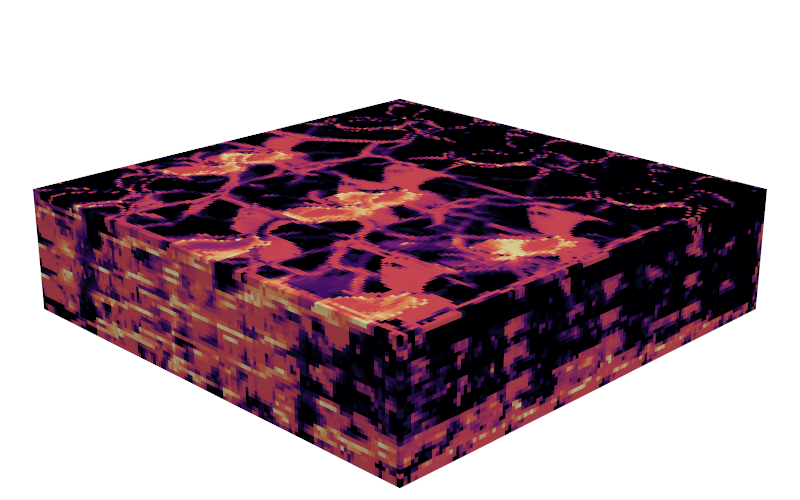


--- Generating 3D PyVista Plot (Run 12 | Mode: COMBINED) ---


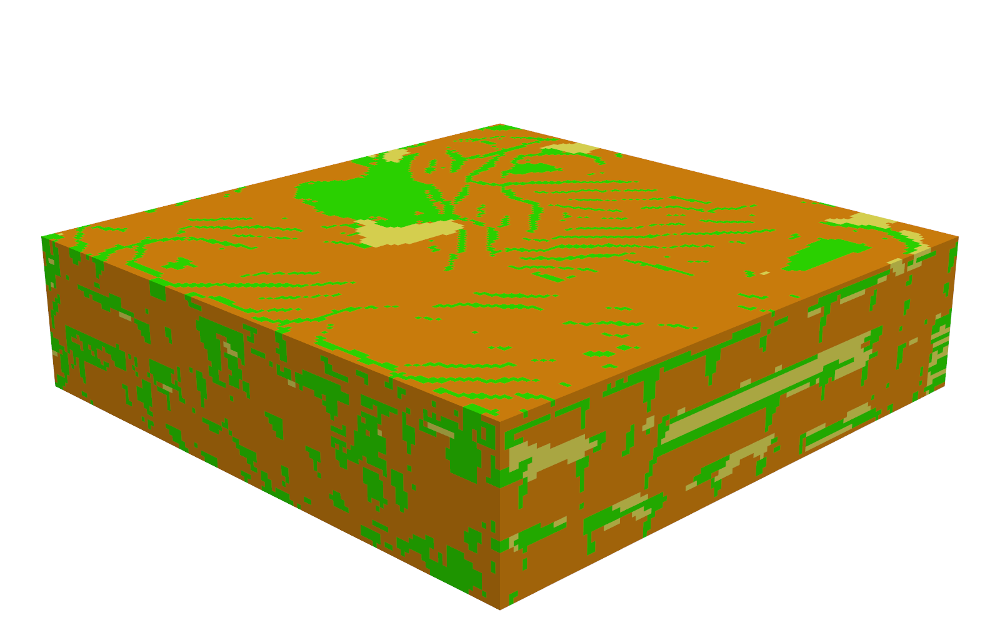

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_disc_iter_2_setting_2\3d_plot_gan_sample_58combined.png

--- Generating 3D PyVista Entropy Map (Run 12) ---
[Run 12] Calculated Mean Voxel-Wise Entropy: 0.6232


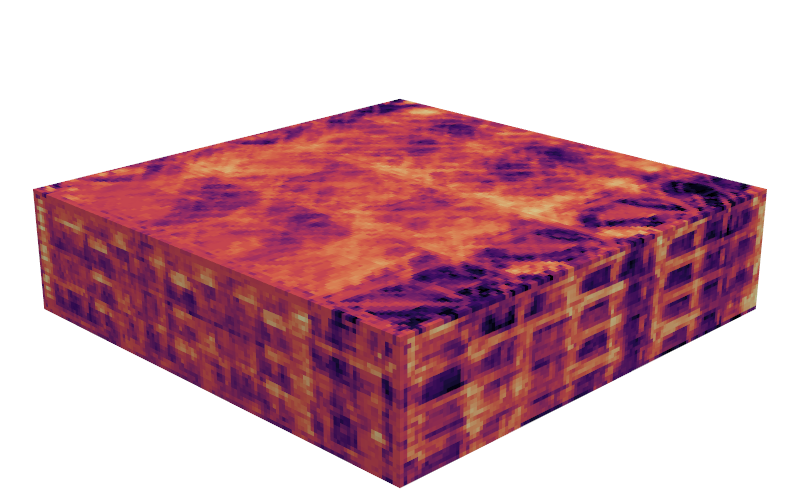

In [5]:
for i, validator in enumerate(validators):
    if i == 0:
        validator.plot_3d_pyvista(data_source='flumy',mode='combined',show_legend=False,show_plot=False, save_plot=True)
        validator.plot_3d_entropy_pyvista(data_source='flumy', show_plot=False, save_plot=True)
        validator.plot_3d_pyvista(mode='combined',show_legend=False,show_plot=False, save_plot=True)
        validator.plot_3d_entropy_pyvista(show_plot=False,save_plot=True)
    else:
        validator.plot_3d_pyvista(mode='combined',show_legend=False,show_plot=False, save_plot=True)
        validator.plot_3d_entropy_pyvista(show_plot=False,save_plot=True)

# **2. Global evaluation metrics**



## **2.1 Facies distribution**



--- Generating Facies Distribution (Mode: FLUMY) ---


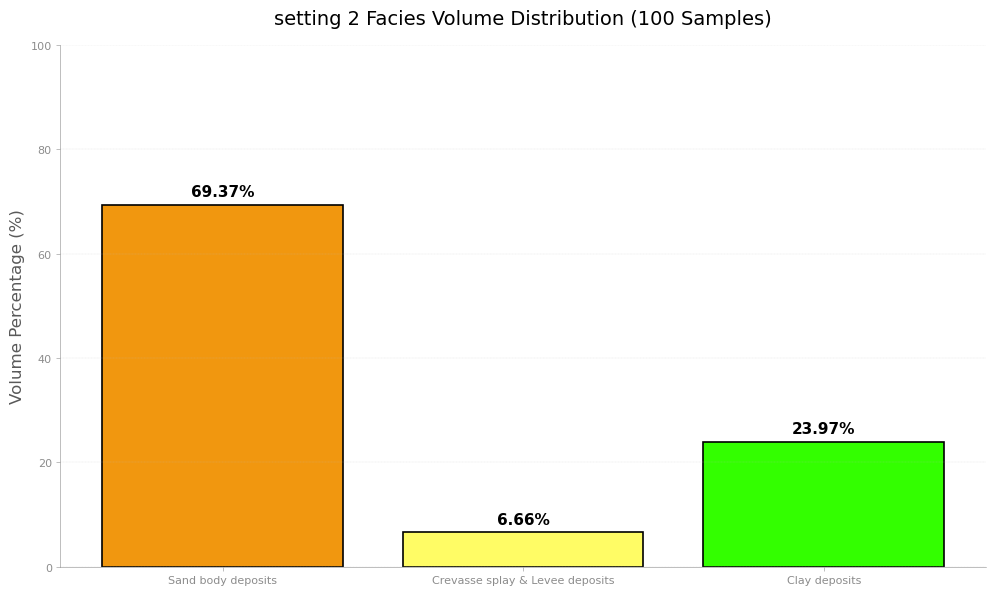


--- Generating Facies Distribution (Mode: BOTH) ---


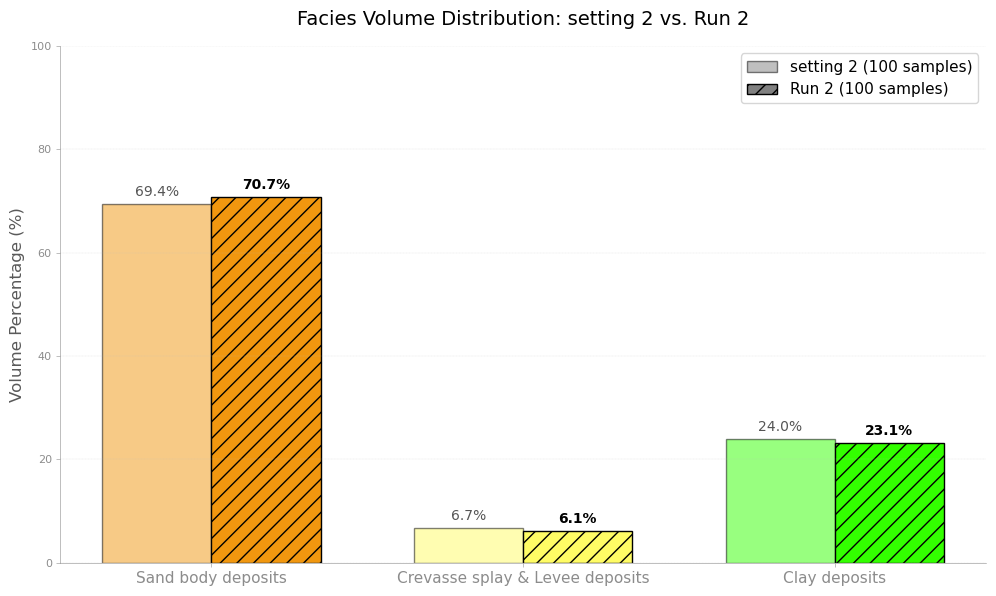


--- Generating Facies Distribution (Mode: BOTH) ---


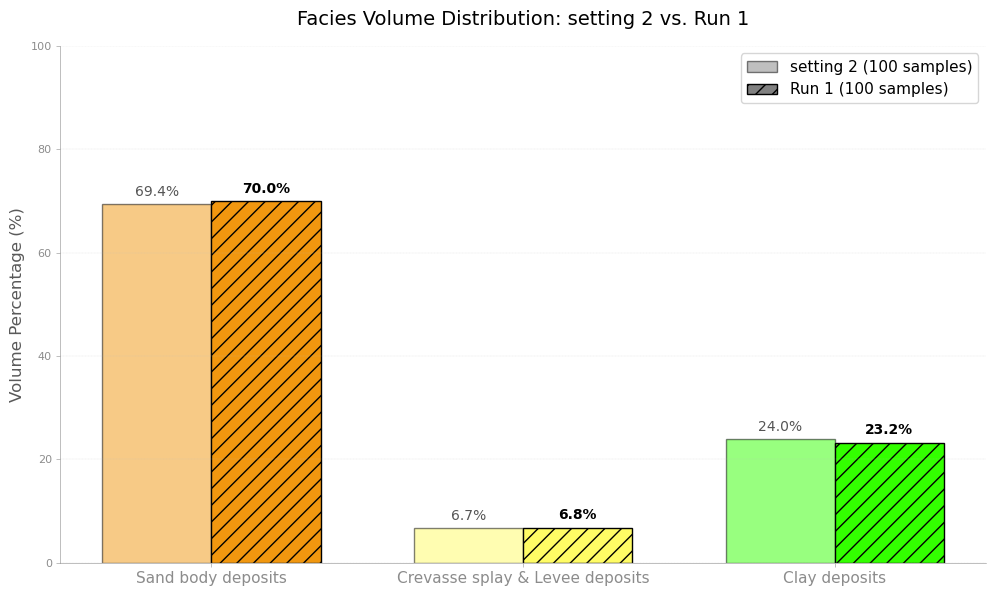


--- Generating Facies Distribution (Mode: BOTH) ---


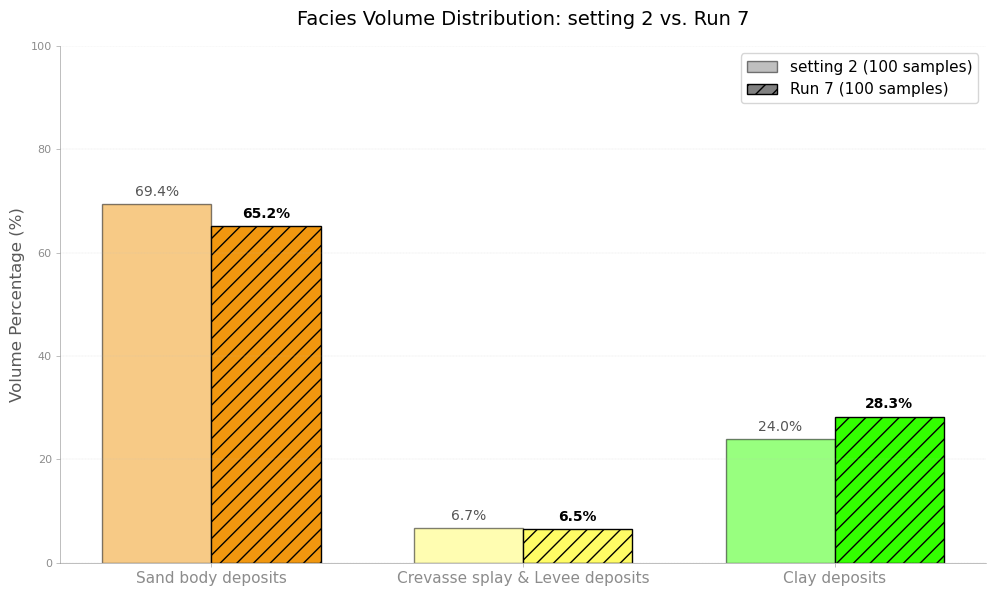


--- Generating Facies Distribution (Mode: BOTH) ---


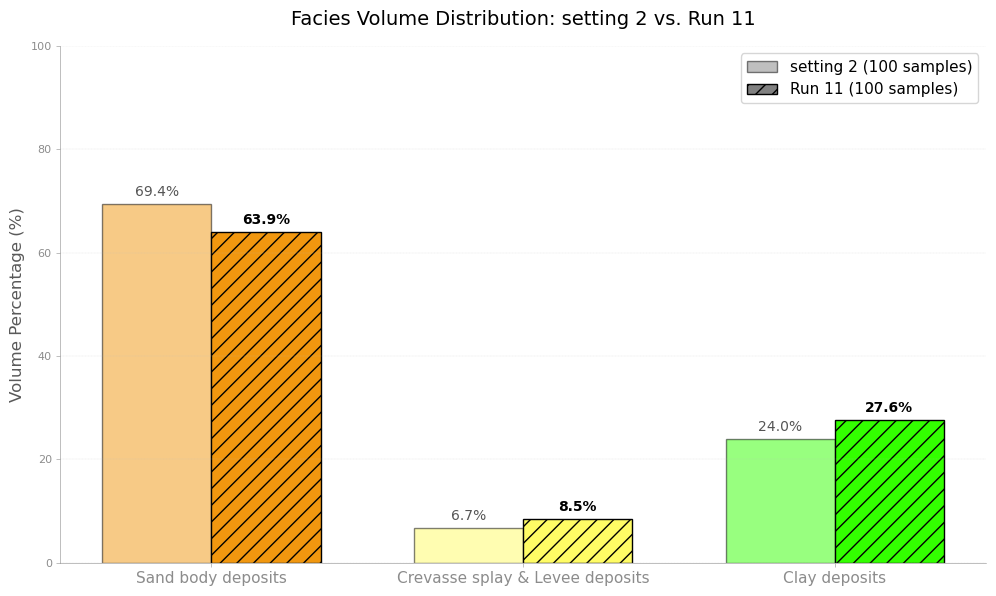


--- Generating Facies Distribution (Mode: BOTH) ---


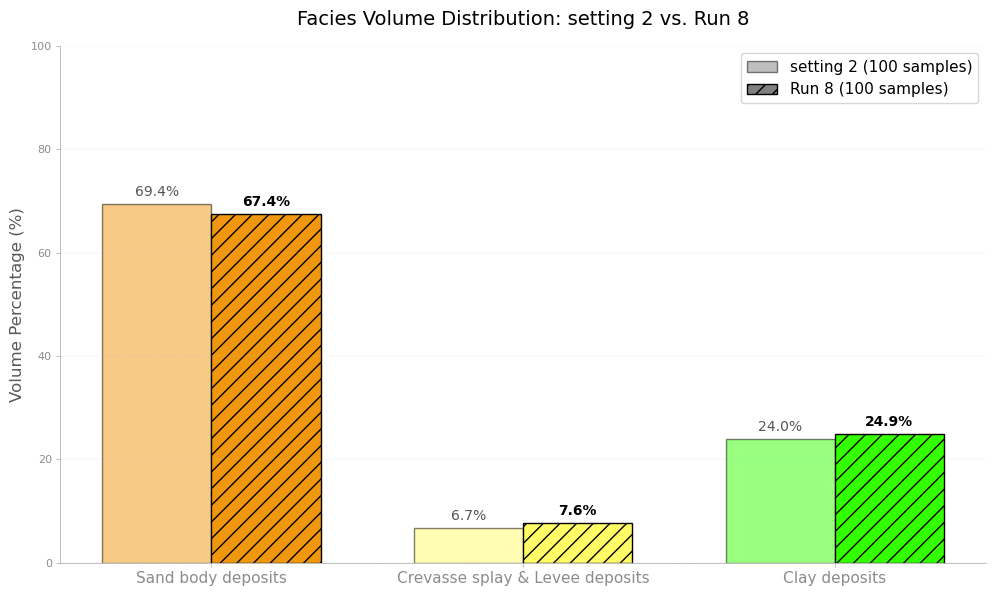


--- Generating Facies Distribution (Mode: BOTH) ---


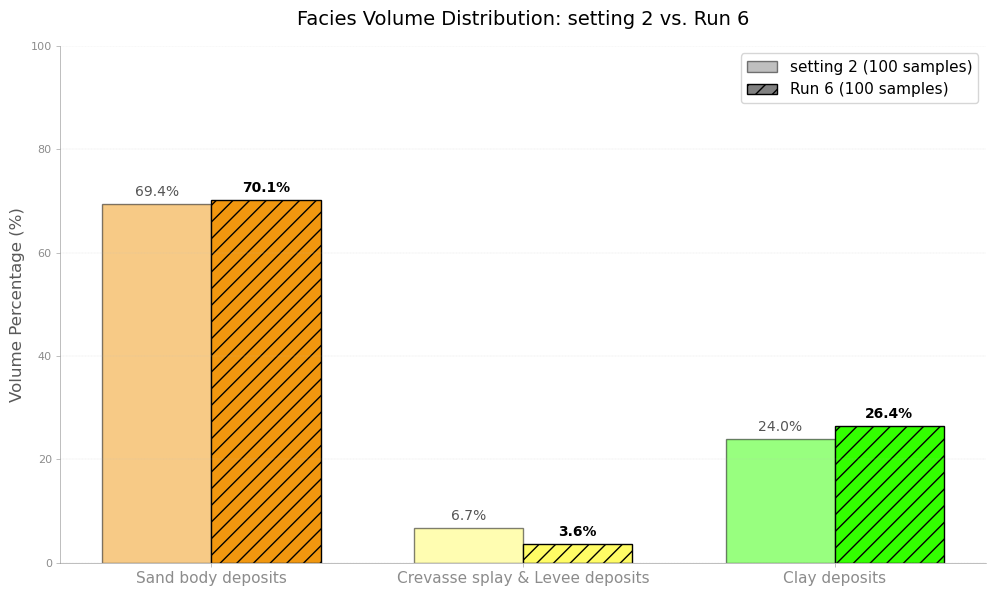


--- Generating Facies Distribution (Mode: BOTH) ---


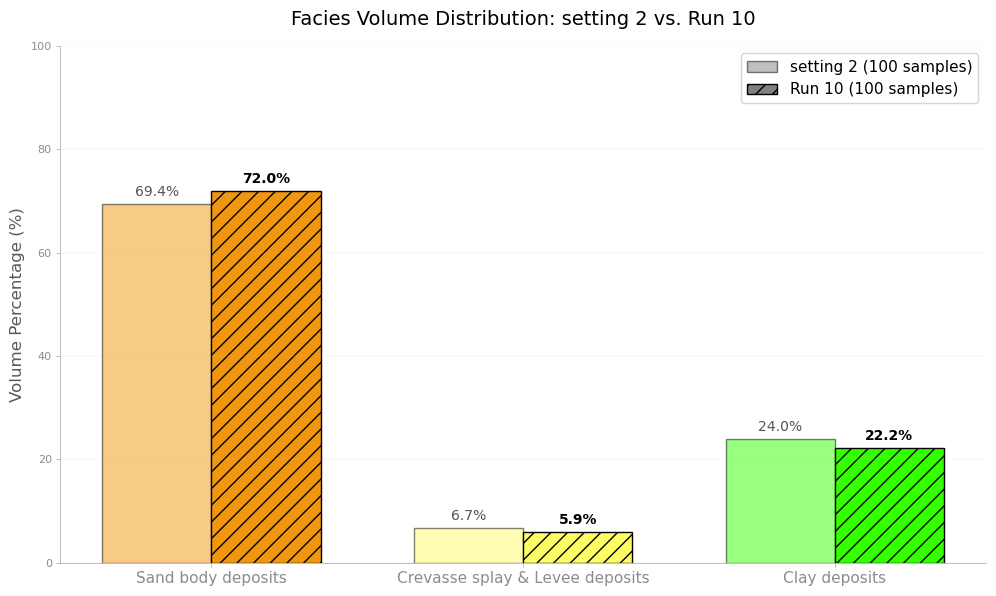


--- Generating Facies Distribution (Mode: BOTH) ---


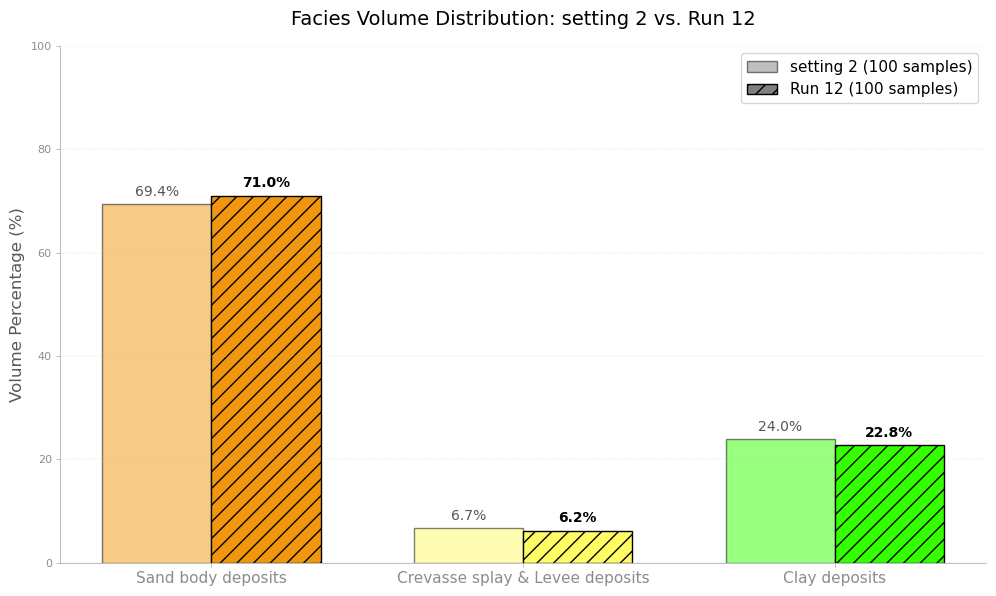

In [6]:
for i, validator in enumerate(validators):
    if i ==0:
        validator.plot_facies_percentages(mode='flumy',show_plot=True, save_plot=False)
        validator.plot_facies_percentages(mode='both',show_plot=True, save_plot=False)
    else:
        validator.plot_facies_percentages(mode='both',show_plot=True, save_plot=False)


## **2.2 Connectivity and patterns analysis**

In [7]:
# def plot_multi_run_pattern_comparison(run_data_dict, facies_list, baseline_name="Flumy"):
#     """
#     Compares 2D pattern frequencies across multiple GAN runs against a baseline.
    
#     Args:
#         run_data_dict (dict): Dictionary of {run_label: raw_run_data} from the loop.
#         facies_list (list): List of facies codes to analyze.
#         baseline_name (str): Label for the baseline dataset.
#     """
#     import matplotlib.cm as cm
    
#     # Fetch the first run's data to extract the baseline patterns
#     first_run_payload = next(iter(run_data_dict.values()))
#     flumy_patterns = first_run_payload['flumy_patterns']
    
#     for f_val in facies_list:
#         plt.figure(figsize=(7, 6))
        
#         # Filter baseline patterns for this facies (assuming center voxel defines the facies)
#         f_flumy = {p: c for p, c in flumy_patterns.items() if p[len(p)//2] == f_val}
#         total_flumy = sum(f_flumy.values()) if f_flumy else 1
        
#         # Define a color map for the different runs
#         colors = cm.rainbow(np.linspace(0, 1, len(run_data_dict)))
        
#         # Track maximum frequency for dynamic plot limits
#         global_max_freq = 0.01 
        
#         # Plot each run's data points
#         for (run_label, payload), color in zip(run_data_dict.items(), colors):
#             gan_patterns = payload['gan_patterns']
#             f_gan = {p: c for p, c in gan_patterns.items() if p[len(p)//2] == f_val}
#             total_gan = sum(f_gan.values()) if f_gan else 1
            
#             # Find all unique patterns present in either dataset for this facies
#             all_patterns = set(f_flumy.keys()).union(set(f_gan.keys()))
            
#             flumy_freqs = []
#             gan_freqs = []
#             for p in all_patterns:
#                 f_freq = f_flumy.get(p, 0) / total_flumy
#                 g_freq = f_gan.get(p, 0) / total_gan
#                 flumy_freqs.append(f_freq)
#                 gan_freqs.append(g_freq)
                
#                 global_max_freq = max(global_max_freq, f_freq, g_freq)
            
#             plt.scatter(flumy_freqs, gan_freqs, alpha=0.5, color=color, label=run_label, s=20)
        
#         # Draw a perfect 1:1 match reference line
#         plt.plot([0, global_max_freq * 1.1], [0, global_max_freq * 1.1], 'r--', alpha=0.7, label='Perfect Alignment')
        
#         plt.title(f"MPS Pattern Frequency Comparison — Facies {f_val}")
#         plt.xlabel(f"{baseline_name} Relative Frequency")
#         plt.ylabel("GAN Variants Relative Frequency")
#         plt.xlim(0, global_max_freq * 1.1)
#         plt.ylim(0, global_max_freq * 1.1)
#         plt.grid(True, linestyle=':', alpha=0.6)
#         plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#         plt.tight_layout()
#         plt.show()

# def plot_multi_run_connectivity_comparison(run_data_dict, facies_list, baseline_name="Flumy"):
#     """
#     Plots a side-by-side boxplot comparison of macro-connectivity blob sizes
#     for multiple validator runs against the baseline.
#     """
#     for f_val in facies_list:
#         plot_data = []
        
#         # Extract baseline data from the first run's payload
#         first_run_payload = next(iter(run_data_dict.values()))
#         baseline_blobs = first_run_payload['flumy_blobs'].get(f_val, [])
#         for size in baseline_blobs:
#             plot_data.append({'Model/Run': baseline_name, 'Connected Object Size': size})
            
#         # Extract generator data across all validator runs
#         for run_label, payload in run_data_dict.items():
#             gan_blobs = payload['gan_blobs'].get(f_val, [])
#             for size in gan_blobs:
#                 plot_data.append({'Model/Run': run_label, 'Connected Object Size': size})
                
#         df_plot = pd.DataFrame(plot_data)
        
#         if df_plot.empty:
#             print(f"No connectivity data available for Facies {f_val}")
#             continue
            
#         plt.figure(figsize=(12, 6))
#         # Log scale handles the massive volumetric range of 3D geological bodies
#         sns.boxplot(data=df_plot, x='Model/Run', y='Connected Object Size', palette='Set3')
#         plt.yscale('log')
#         plt.title(f"3D Connected Voxel Distribution — Facies {f_val}")
#         plt.ylabel("Connected Object Size (Voxels — Log Scale)")
#         plt.xlabel("Evaluation Target")
#         plt.grid(True, which="both", linestyle=":", alpha=0.5)
#         plt.xticks(rotation=15)
#         plt.tight_layout()
#         plt.show()

In [8]:
# all_runs_comparison_data = {}

# for i, validator in enumerate(validators):
#     # Determine a label for this specific run
#     run_label = getattr(validator, 'gan_name', f"CGAN_Run_{i}")
#     print(f"Processing validator {i+1}/{len(validators)}: {run_label}")
    
#     df_stats, run_data = validator.connectivity_and_pattern_analysis(plot=False)
    
#     all_runs_comparison_data[run_label] = run_data

# # Specify the facies codes you want to plot (e.g., [0, 1, 2])
# target_facies = validators[0].cfg['codes']

# # 1. Compare the 2D pattern matching accuracy across all runs
# plot_multi_run_pattern_comparison(all_runs_comparison_data, facies_list=target_facies)

# # 2. Compare the structural object sizes across all runs
# plot_multi_run_connectivity_comparison(all_runs_comparison_data, facies_list=target_facies)

## **2.3 Multidimesional scaled plots**

In [9]:
# # Initialize a shared DistributionEvaluator (output_dir determines where the plot is saved)
# dist_eval = DistributionEvaluator(output_dir_gan_8_1)

# # Initialize PostProcessing to easily load the GAN and Flumy datasets
# pp_run6 = PostProcessing('Flumy', 'Run 6', output_dir_gan_06, data_dir_2, gan_data_dir_06)
# pp_run6.load_gan_samples(limit=100) # Optional limit for speed/memory
# dist_eval.compute_embedding(pp_run6.gan_data, 'Run 6', save_dir=output_dir_gan_06)

# pp_run8_1 = PostProcessing('Flumy', 'Run 8.1', output_dir_gan_8_1, data_dir_2, gan_data_dir_8_1)
# pp_run8_1.load_gan_samples(limit=100)
# dist_eval.compute_embedding(pp_run8_1.gan_data, 'Run 8.1', save_dir=output_dir_gan_8_1)

# # Also ensure Flumy data embedding is computed
# pp_run8_1.load_flumy_samples(limit=100)
# dist_eval.compute_embedding(pp_run8_1.flumy_samples, 'Flumy', save_dir=output_dir_gan_8_1)

# # Now plot them together
# datasets = {
#     'Flumy': output_dir_gan_8_1,
#     'Run 6': output_dir_gan_06,
#     'Run 8.1': output_dir_gan_8_1
# }
# fig, ax = dist_eval.plot_multi_mds(datasets)


# **3. Local evaluation metrics**

## **3.1 2D Normalized Entropy plots**


--- Generating Run 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


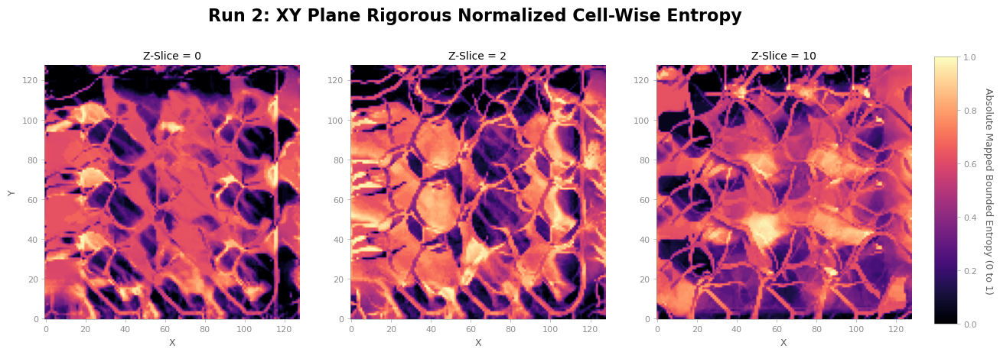


--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


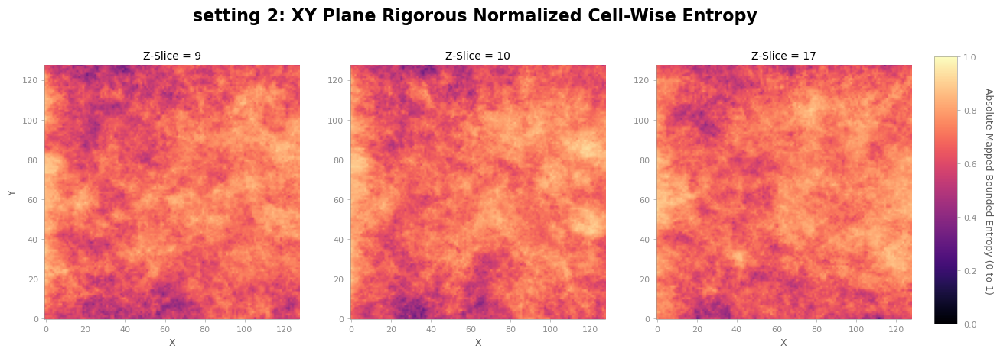


--- Generating Run 1 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


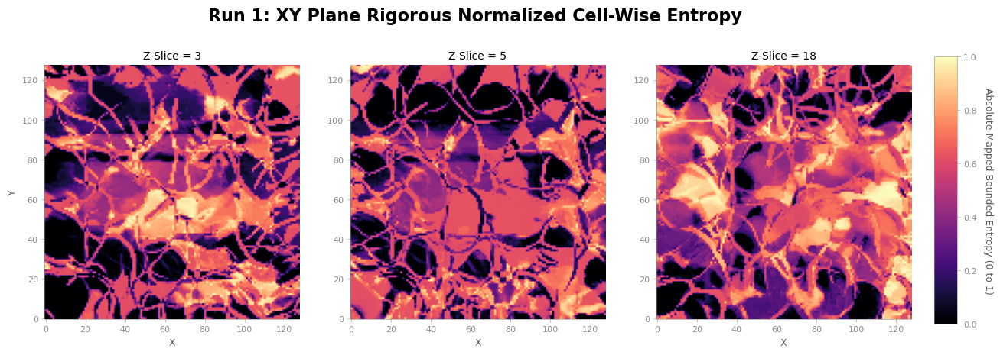


--- Generating Run 7 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


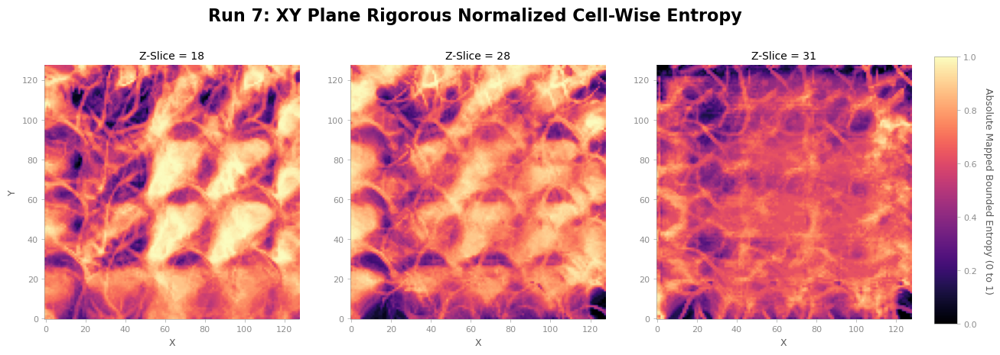


--- Generating Run 11 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


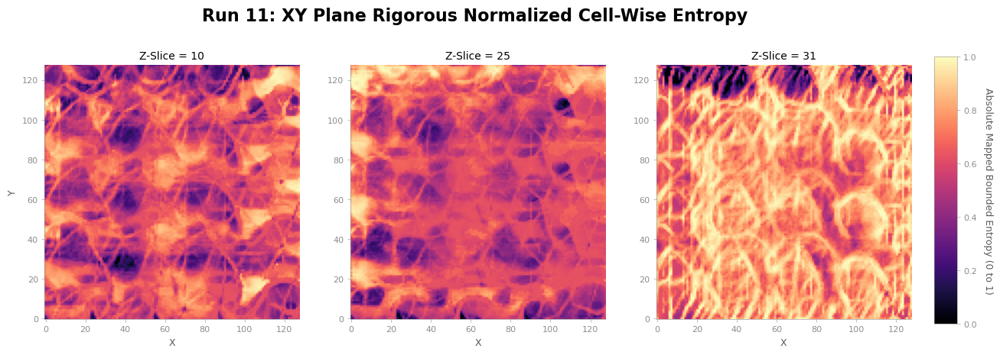


--- Generating Run 8 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


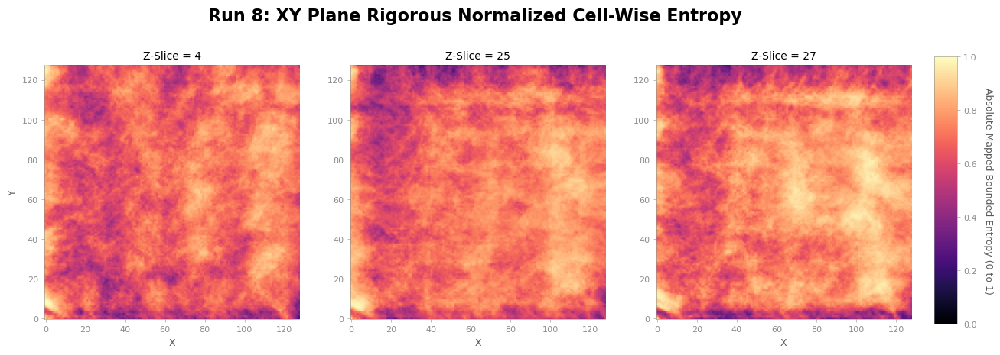


--- Generating Run 6 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


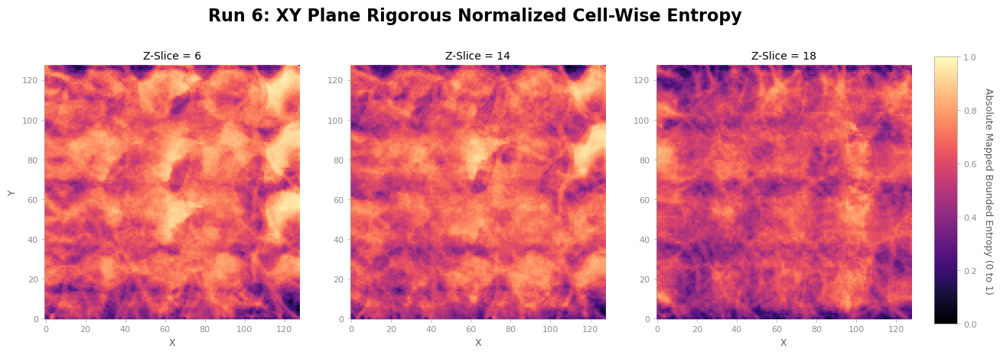


--- Generating Run 10 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


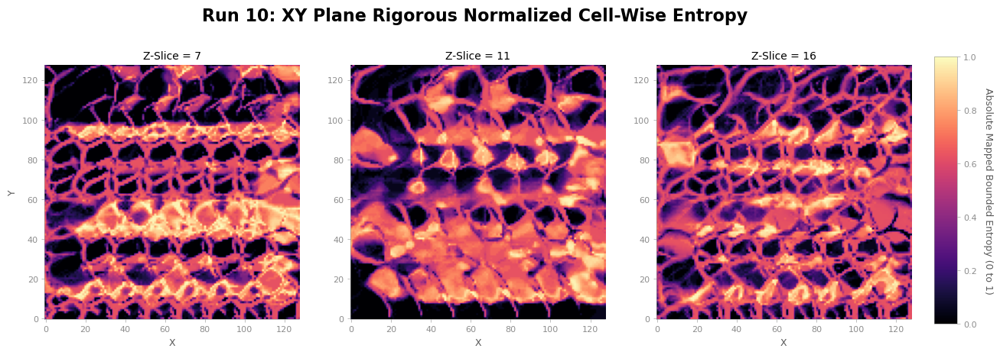


--- Generating Run 12 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


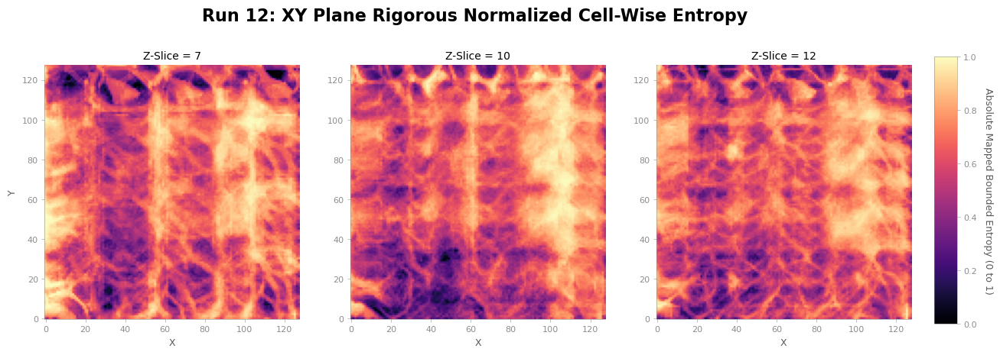

In [10]:
for i, validator in enumerate(validators):
    if i == 1:
        validator.plot_entropy(data_source='flumy',axis='Z',num_slices=3,show_plot=True, save_plot=False)
        validator.plot_entropy(axis='Z', num_slices=3,show_plot=True, save_plot=False)
    else:
        validator.plot_entropy(axis='Z', num_slices=3,show_plot=True, save_plot=False)

## **3.2 Jensen-Shannon Divergence calculations**


--- Computing Scalar Metrics comparing Run 2 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 2 Model Entropy:  0.5146 ± 0.0554
Model-to-Baseline Spatial Entropy Ratio: 0.7434


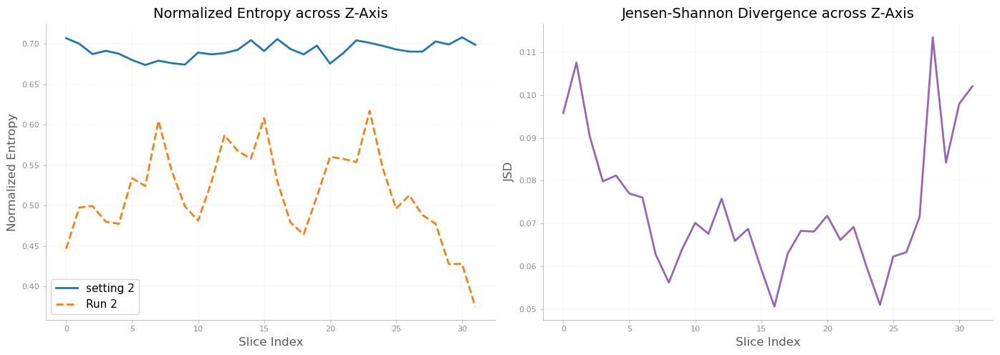


--- Computing Scalar Metrics comparing Run 1 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 1 Model Entropy:  0.4304 ± 0.0489
Model-to-Baseline Spatial Entropy Ratio: 0.6217


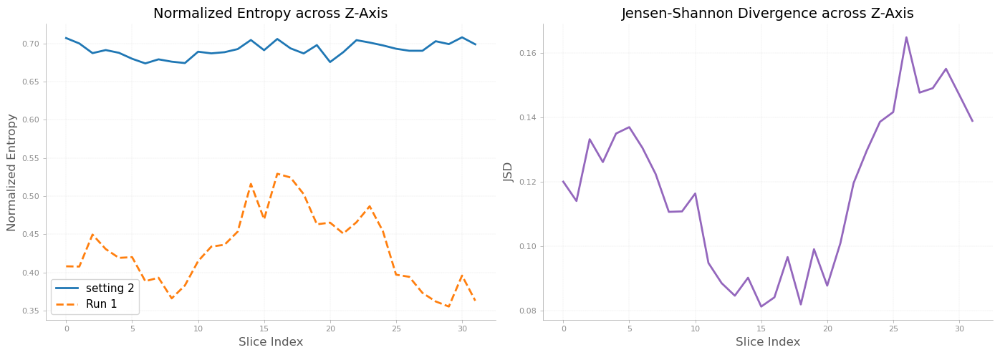


--- Computing Scalar Metrics comparing Run 7 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 7 Model Entropy:  0.6374 ± 0.0434
Model-to-Baseline Spatial Entropy Ratio: 0.9209


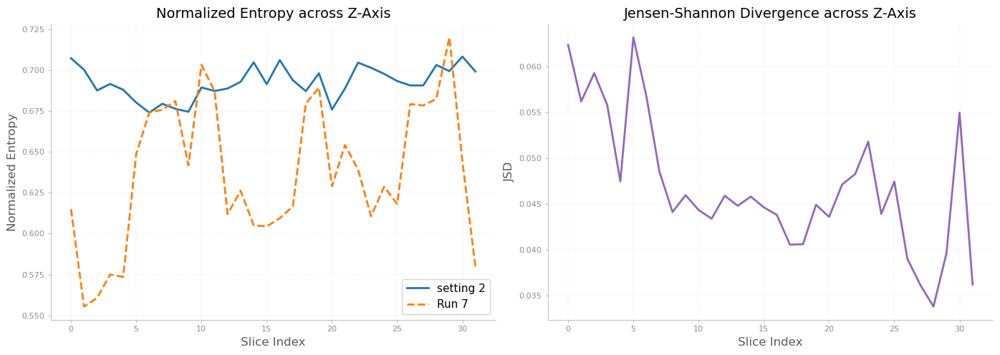


--- Computing Scalar Metrics comparing Run 11 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 11 Model Entropy:  0.6292 ± 0.1185
Model-to-Baseline Spatial Entropy Ratio: 0.9090


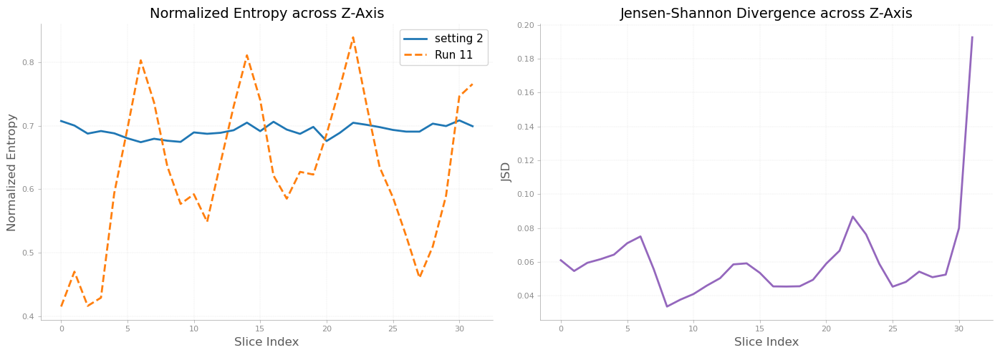


--- Computing Scalar Metrics comparing Run 8 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 8 Model Entropy:  0.7037 ± 0.0330
Model-to-Baseline Spatial Entropy Ratio: 1.0166


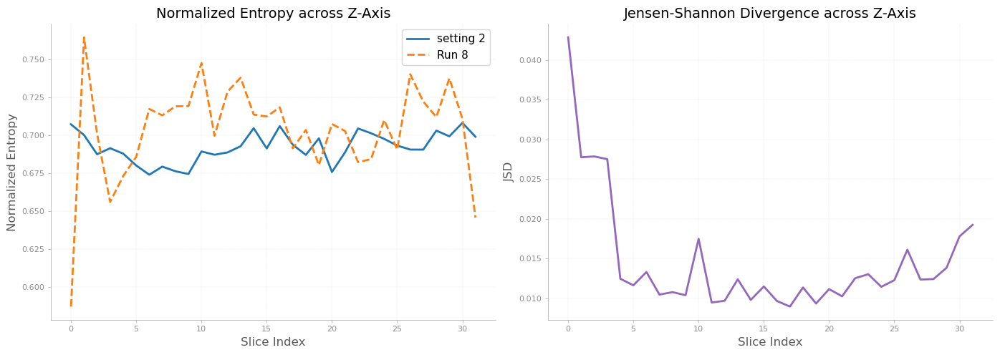


--- Computing Scalar Metrics comparing Run 6 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 6 Model Entropy:  0.6141 ± 0.0420
Model-to-Baseline Spatial Entropy Ratio: 0.8872


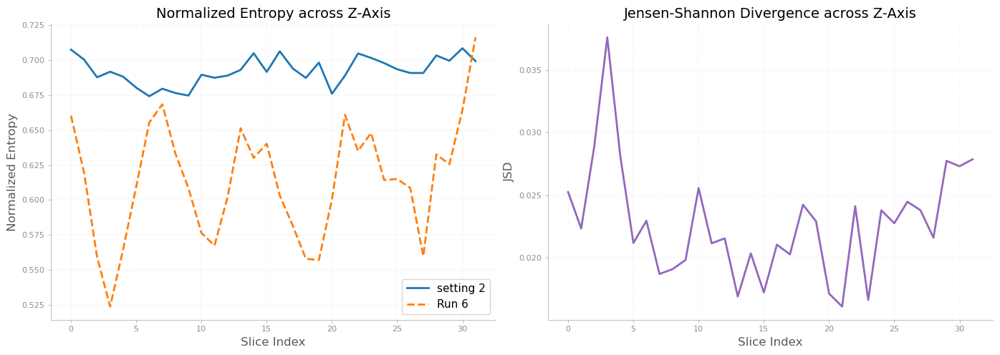


--- Computing Scalar Metrics comparing Run 10 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 10 Model Entropy:  0.3926 ± 0.0800
Model-to-Baseline Spatial Entropy Ratio: 0.5671


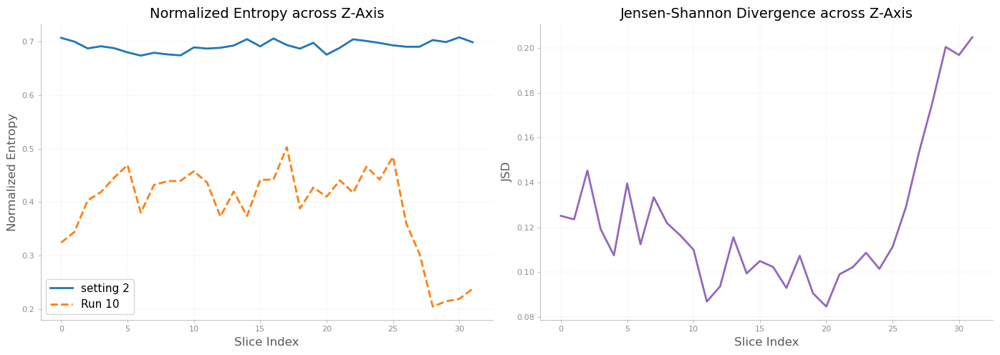


--- Computing Scalar Metrics comparing Run 12 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 12 Model Entropy:  0.6232 ± 0.0390
Model-to-Baseline Spatial Entropy Ratio: 0.9004


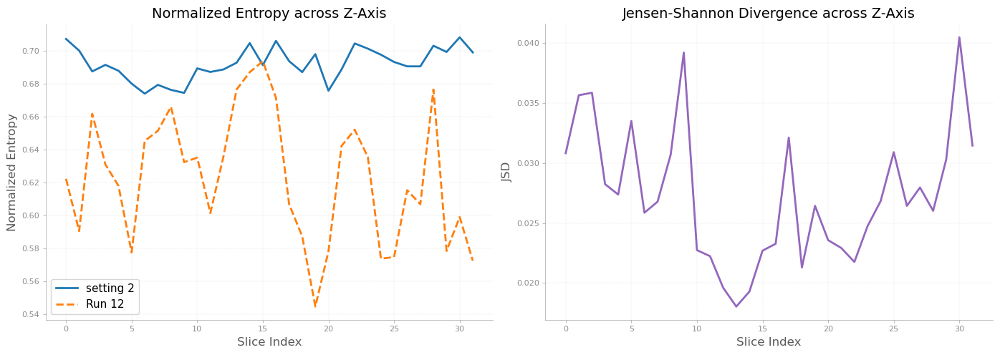

In [11]:
JSD_list = []

for i, validator in enumerate(validators):
    JSD = validator.compute_slice_metrics(plot=True)
    JSD_list.append(JSD)

## **3.4 Global metrics overview**

| Run name/number    |  JSD Z axis (Real vs GAN) | Best JS Divergence (X ax) | Best JS Divergence (Y ax) | Additional observations   |
| :---          | :---                      | :---                      | :---                      | :---                      |
|     1         |     0.1161 ± 0.0243       |                           |                           |                           |
|     2         |     0.0718 ± 0.0157       |                           |                           |                           |
|     3         |     0.0449 ± 0.0083       |                           |                           |                           |
|     4         |     0.0869 ± 0.0202       |                           |                           |                           |
|     5         |     0.0393 ± 0.0108       |                           |                           |                           |
|     6         |     0.0202 ± 0.0038       |                           |                           |                           |
|     7         |     0.0458 ± 0.0076       |                           |                           |                           |
|     8         |     0.0155 ± 0.0067       |                           |                           |                           |
|     8.1       |     0.0146 ± 0.0082       |                           |                           |                           |
|     9         |     0.0511 ± 0.0147       |                           |                           |                           |
|     10        |     0.1190 ± 0.0324       |                           |                           |                           |
|     11        |     0.0612 ± 0.0314       |                           |                           |                           |
|     12        |     0.0278 ± 0.0045       |                           |                           |                           |
|     13        |     0.0278 ± 0.0045       |                           |                           |                           |
|     14        |     0.0278 ± 0.0045       |                           |                           |                           |
|     All       |     0.0176 ± 0.0059       |                           |                           |                           |


**Discussion:** The Boundaries are Failing (Slice 0 & 31): The JSD more than doubles at Slice 0 (0.154) and worsens at Slice 31 (0.087). This is a classic symptom of 3D convolutional neural networks. Because convolutions require padding at the edges of 3D tensors, GANs frequently struggle to resolve accurate spatial geometries at the outermost boundary layers compared to the inner volume.

# **4. Report Plots**

## **Figure 4.2**

Formatting full-page A4 canvas grid via GridSpec for 8 runs...

Run: Run 1: FluvGAN | True Calculated Mean Entropy (H): 0.51462
Run: Run 2: Run 1 + double conv | True Calculated Mean Entropy (H): 0.43038
Run: Run 3: Run 2 + double resblock | True Calculated Mean Entropy (H): 0.63743
Run: Run 4: Run 3 + penalty 1 | True Calculated Mean Entropy (H): 0.62923
Run: Run 5: Run 3 + penalty 2 | True Calculated Mean Entropy (H): 0.70370
Run: Run 6: Run 3 + penalty 3 | True Calculated Mean Entropy (H): 0.61410
Run: Run 7: Run 5 less samples | True Calculated Mean Entropy (H): 0.39257
Run: Run 8: Run 5 less iterations discriminator | True Calculated Mean Entropy (H): 0.62324

[Exported Successfully] GridSpec report sheet saved directly to:
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\gridspec_A4_metrics_matrix.png


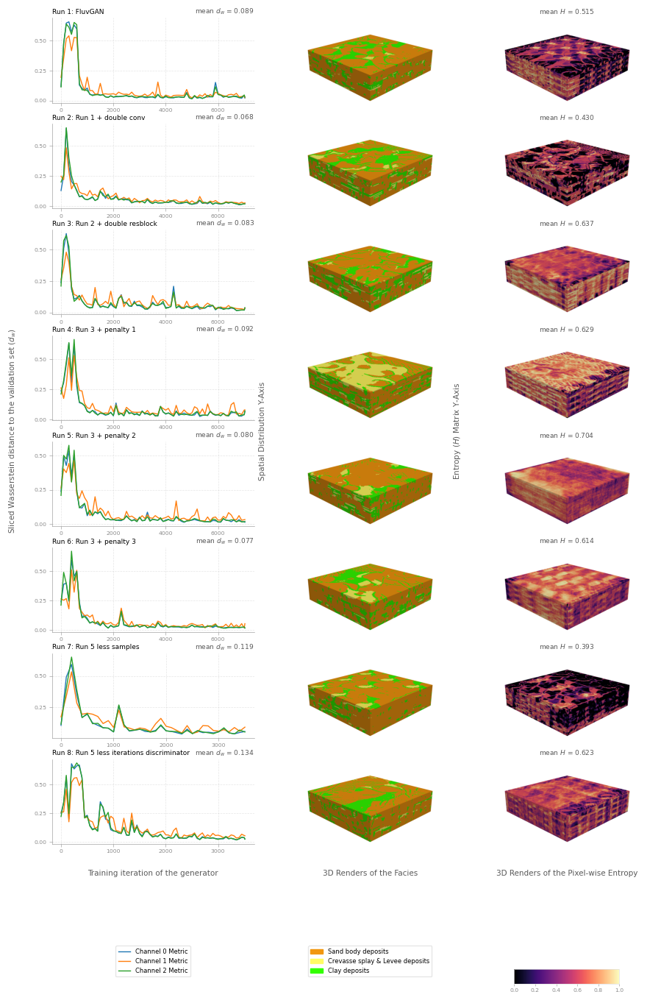

In [13]:
import warnings
from scipy.stats import entropy

def calculate_mean_entropy(validator):
    """Replicates the strict scalar metric calculation from PostProcessing.compute_slice_metrics."""
    try:
        # 1. Gather ensemble data dynamically if not already memory-resident
        if not validator.gan_data:
            validator.load_gan_samples()
        if not validator.flumy_samples:
            validator.load_flumy_samples()
            
        target_data = validator.gan_data
        num_realizations = len(target_data)
        
        # 2. Compute TRUE h_max normalization factor (NO 1.3 visual multiplier)
        flumy_global_probs = validator._get_global_proportions(validator.flumy_samples)
        h_max = validator._calculate_h_max(flumy_global_probs)
        
        # 3. Compute cell-wise probabilities across the ensemble
        nz, ny, nx = target_data[0].shape
        facies_values = validator.cfg['codes']
        
        probs = np.zeros((len(facies_values), nz, ny, nx))
        ensemble_stack = np.stack(target_data, axis=0)
        
        for i, f_val in enumerate(facies_values):
            probs[i] = np.sum(ensemble_stack == f_val, axis=0) / num_realizations

        # 4. Calculate and normalize Shannon Entropy cell-by-cell
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # Calculate 3D Voxel-wise Entropy
            entropy_map = entropy(probs, base=2, axis=0)
            
            if h_max > 0:
                entropy_map = entropy_map / h_max
                
        # 5. Return the overall spatial scalar mean using nanmean (matching postprocessing.py)
        return float(np.nanmean(entropy_map))
        
    except Exception as e:
        print(f"[{validator.gan_desc}] Optimization warning: Could not resolve mean entropy matrix on the fly -> {e}")
        return None


def plot_metric_history(ax, csv_path, run_name):
    """Parses training logs, handles line plotting, and displays the mean DW value."""
    if not os.path.exists(csv_path):
        ax.text(0.5, 0.5, "Missing History Log", ha='center', va='center', color='orange', fontsize=6)
        ax.axis('off')
        print(f"[{run_name}] Missing History Log - Cannot compute mean SWD")
        return None

    try:
        df = pd.read_csv(csv_path)
        metric_cols = ['MS-SWD_Ch0', 'MS-SWD_Ch1', 'MS-SWD_Ch2']
        for col in metric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Connect the 100-iteration validation points cleanly
        df_metrics = df.dropna(subset=['MS-SWD_Ch0'])
        x_axis = 'iteration'
        
        # Calculate overall mean SWD across all three channels
        mean_ch0 = df_metrics['MS-SWD_Ch0'].mean()
        mean_ch1 = df_metrics['MS-SWD_Ch1'].mean()
        mean_ch2 = df_metrics['MS-SWD_Ch2'].mean()
        mean_swd = np.mean([mean_ch0, mean_ch1, mean_ch2])
        
        # Plot channels using standard line properties
        l0, = ax.plot(df_metrics[x_axis], df_metrics['MS-SWD_Ch0'], color='tab:blue', linewidth=1.0, markersize=1.5)
        l1, = ax.plot(df_metrics[x_axis], df_metrics['MS-SWD_Ch1'], color='tab:orange', linewidth=1.0, markersize=1.5)
        l2, = ax.plot(df_metrics[x_axis], df_metrics['MS-SWD_Ch2'], color='tab:green', linewidth=1.0, markersize=1.5)
        
        # Axis titles and inline metrics placement (Placing mean DW text directly above the plot area)
        ax.set_title(run_name, fontsize=6.5, pad=4, loc='left')
        ax.text(1.0, 1.05, f"mean $d_w$ = {mean_swd:.3f}", fontsize=6.5, color='#595959', ha='right', va='baseline', transform=ax.transAxes)
        
        ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.tick_params(axis='both', which='major', labelsize=5.5, pad=2)
        
        return [l0, l1, l2]
        
    except Exception as e:
        ax.text(0.5, 0.5, "Error Processing CSV", ha='center', va='center', color='red', fontsize=6)
        ax.axis('off')
        print(f"[{run_name}] Error processing CSV: {str(e)}")
        return None


def plot_render_sample(ax, plot_dir, search_pattern, error_msg, mean_metric_text=None):
    """Safely locates and renders 3D visualization matrices with optional top text labels."""
    search_path = os.path.join(plot_dir, search_pattern)
    matching_files = glob.glob(search_path)
    
    if matching_files:
        latest_file_path = max(matching_files, key=os.path.getctime)
        img = mpimg.imread(latest_file_path)
        ax.imshow(img, aspect='equal')
        
        # If a mean metric text label is provided, display it just above the 3D plot area
        if mean_metric_text:
            ax.text(0.5, 1.05, mean_metric_text, fontsize=6.5, color='#595959', ha='center', va='baseline', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, error_msg, ha='center', va='center', color='red', fontsize=6)
        
    ax.axis('off')


def plot_shared_label(ax, label, is_vertical=False, pad=12):
    """Constructs a clean background label plane using transparent axis coordinates."""
    ax.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
    ax.grid(False)
    if is_vertical:
        ax.set_ylabel(label, fontsize=7.5, labelpad=pad)
    else:
        ax.set_xlabel(label, fontsize=7.5, labelpad=pad)


def plot_sleek_colorbar(shared_axis, cmap='magma', vmin=0.0, vmax=1.0):
    """Generates a low-profile standalone horizontal colorbar matching the requested height."""
    ax_cbar = inset_axes(
        shared_axis,
        width="65%",          
        height="1.8%",        
        loc='lower center',
        bbox_to_anchor=(0.0, -0.17, 1.0, 1.0), 
        bbox_transform=shared_axis.transAxes,
        borderpad=0
    )
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cb = fig.colorbar(sm, cax=ax_cbar, orientation='horizontal')
    cb.ax.tick_params(labelsize=5.5, pad=2, length=2)
    cb.outline.set_edgecolor('#E0E0E0')
    cb.outline.set_linewidth(0.5)


# ==============================================================================
# MAIN CANVAS ASSEMBLY BLOCK
# ==============================================================================

n_runs = len(validators)
fig = plt.figure(figsize=(8.27, 11.69))

# GridSpec: 3 columns with dedicated horizontal text spacing allocation
gs = gridspec.GridSpec(n_runs, 3, width_ratios=[1, 0.8, 0.8])
gs.update(hspace=0.25, wspace=0.2, bottom=0.02, top=0.98, left=0.01, right=0.99)

global_handles, global_labels = None, None
print(f"Formatting full-page A4 canvas grid via GridSpec for {n_runs} runs...\n")

# Populate the matrix canvas rows sequentially
for idx, validator in enumerate(validators):
    ax_metric = fig.add_subplot(gs[idx, 0])
    ax_render = fig.add_subplot(gs[idx, 1])
    ax_entropy = fig.add_subplot(gs[idx, 2])
    
    # Process and build history metrics (Column 1)
    csv_path = ""
    if hasattr(validator, 'gan_files') and validator.gan_files:
        run_root = os.path.dirname(os.path.dirname(validator.gan_files[0]))
        csv_path = os.path.join(run_root, 'fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv')
        
    handles = plot_metric_history(ax_metric, csv_path, validator.gan_desc)
    if handles and global_handles is None:
        global_handles = handles
        global_labels = ["Channel 0 Metric", "Channel 1 Metric", "Channel 2 Metric"]

    # --- COMPUTE MEAN ENTROPY ON THE FLY ---
    mean_entropy_val = calculate_mean_entropy(validator)    
    entropy_text = f"mean $H$ = {mean_entropy_val:.3f}" if mean_entropy_val is not None else ""
    
    if mean_entropy_val is not None:
        print(f"Run: {validator.gan_desc:<12} | True Calculated Mean Entropy (H): {mean_entropy_val:.5f}")

    plot_render_sample(ax_render, validator.output_dir, "3d_plot_gan_combined.png", "Render Missing")
    plot_render_sample(ax_entropy, validator.output_dir, "3d_plot_gan_ensemble_entropy.png", "Entropy Missing", mean_metric_text=entropy_text)


# ==============================================================================
# GLOBAL METRIC LABELS & LEGENDS SETUP
# ==============================================================================

# Column 1 global setup
ax_shared_metrics = fig.add_subplot(gs[:, 0], frameon=False)
plot_shared_label(ax_shared_metrics, 'Sliced Wasserstein distance to the validation set ($d_w$)', is_vertical=True, pad=15)
plot_shared_label(ax_shared_metrics, 'Training iteration of the generator', is_vertical=False, pad=12)

if global_handles is not None:
    ax_shared_metrics.legend(
        handles=global_handles, labels=global_labels, 
        loc='upper center', bbox_to_anchor=(0.5, -0.12),  
        ncol=1, fontsize=6, frameon=True, facecolor='white', edgecolor='#E0E0E0'
    )

# Column 2 global setup
ax_shared_render = fig.add_subplot(gs[:, 1], frameon=False)
plot_shared_label(ax_shared_render, 'Spatial Distribution Y-Axis', is_vertical=True, pad=4)
plot_shared_label(ax_shared_render, '3D Renders of the Facies', is_vertical=False, pad=12)

if n_runs > 0:
    cfg = validators[0].cfg
    facies_patches = [mpatches.Patch(color=cfg['colors'][code], label=cfg['names'][code]) for code in cfg['codes']]
    ax_shared_render.legend(
        handles=facies_patches, loc='upper center', bbox_to_anchor=(0.5, -0.12),
        ncol=1, fontsize=6, frameon=True, facecolor='white', edgecolor='#E0E0E0'
    )

# Column 3 global setup
ax_shared_entropy = fig.add_subplot(gs[:, 2], frameon=False)
plot_shared_label(ax_shared_entropy, 'Entropy ($H$) Matrix Y-Axis', is_vertical=True, pad=4)
plot_shared_label(ax_shared_entropy, '3D Renders of the Pixel-wise Entropy', is_vertical=False, pad=12)
plot_sleek_colorbar(ax_shared_entropy, cmap='magma', vmin=0.0, vmax=1.0)


# ==============================================================================
# FILE EXPORT
# ==============================================================================
if n_runs > 0:
    shared_parent_dir = os.path.dirname(validators[0].output_dir)
    final_output_path = os.path.join(shared_parent_dir, "gridspec_A4_metrics_matrix.png")
    plt.savefig(final_output_path, bbox_inches='tight', dpi=600, facecolor='white')
    print(f"\n[Exported Successfully] GridSpec report sheet saved directly to:\n{final_output_path}")

plt.show()

## **Figure 4.3**

Generating layout matrix for Run 8.1 overview...
[Exported Successfully] Summary view saved directly to:
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\mds_samples_overview_matrix.png


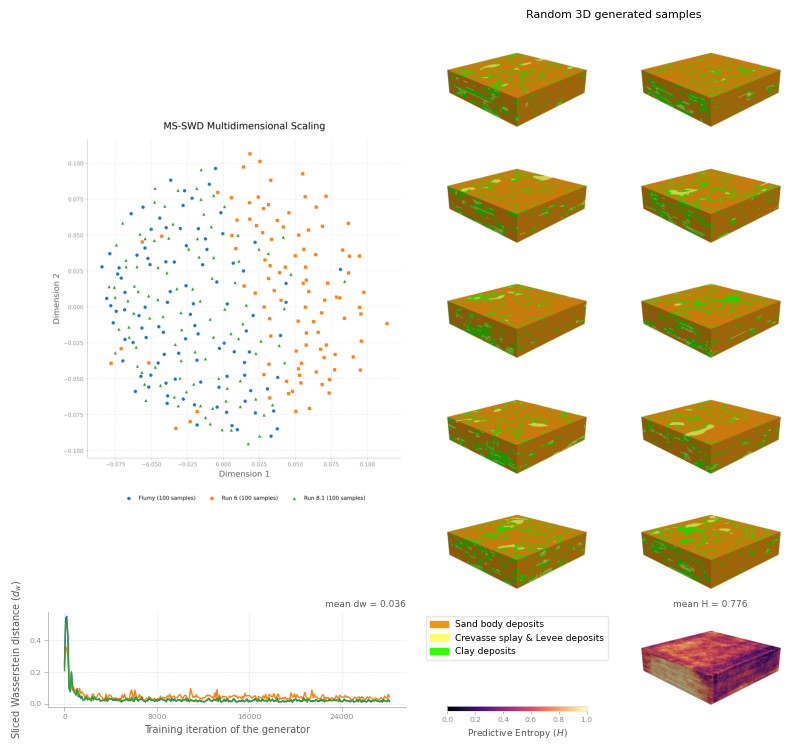

In [126]:
def plot_mds_space(ax, plot_dir, filename="msswd_mds_multi_plot.png"):
    """Loads and renders the global multidimensional scaling plot across Column 1."""
    full_path = os.path.join(plot_dir, filename)
    if os.path.exists(full_path):
        img = mpimg.imread(full_path)
        ax.imshow(img, aspect='equal')
    else:
        ax.text(0.5, 0.5, f"MDS Plot Missing\n({filename})", ha='center', va='center', color='red', fontsize=7)
    ax.axis('off')


def plot_random_3d_samples(axes_list, plot_dir, search_pattern="3d_plot_gan_sample_*.png"):
    """Finds available 3D realizations, selects 10 randomly, and plots them into the grid."""
    search_path = os.path.join(plot_dir, search_pattern)
    available_samples = glob.glob(search_path)
    
    if not available_samples:
        available_samples = glob.glob(os.path.join(plot_dir, "3d_plot_gan_*.png"))
        
    if len(available_samples) >= len(axes_list):
        selected_samples = random.sample(available_samples, len(axes_list))
        for ax, sample_path in zip(axes_list, selected_samples):
            img = mpimg.imread(sample_path)
            ax.imshow(img, aspect='equal')
            ax.axis('off')
    else:
        for i, ax in enumerate(axes_list):
            if i < len(available_samples):
                img = mpimg.imread(available_samples[i])
                ax.imshow(img, aspect='equal')
            else:
                ax.text(0.5, 0.5, "Sample Missing", ha='center', va='center', color='orange', fontsize=6)
            ax.axis('off')


def plot_render_sample(ax, plot_dir, search_pattern, error_msg, mean_metric_text=None):
    """Safely locates and renders 3D visualization matrices with optional top text labels."""
    search_path = os.path.join(plot_dir, search_pattern)
    matching_files = glob.glob(search_path)
    
    if matching_files:
        latest_file_path = max(matching_files, key=os.path.getctime)
        img = mpimg.imread(latest_file_path)
        ax.imshow(img, aspect='equal')
        if mean_metric_text:
            ax.text(0.5, 1.05, mean_metric_text, fontsize=6.5, color='#595959', ha='center', va='baseline', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, error_msg, ha='center', va='center', color='red', fontsize=6)
    ax.axis('off')


def plot_column_header(ax, title, pad=10):
    """Establishes an invisible tracking plane to position column headers cleanly."""
    ax.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
    ax.grid(False)
    ax.set_title(title, fontsize=8, pad=pad, color='black', loc='center')


# ==============================================================================
# MAIN CANVAS ASSEMBLY BLOCK
# ==============================================================================

target_validator = validator_8_1 
run_name = target_validator.gan_name
plot_dir = target_validator.output_dir

# Initializing figure canvas layout properties
fig = plt.figure(figsize=(8.27, 8.0))

gs = gridspec.GridSpec(6, 4)
gs.update(hspace=0.22, wspace=0.18, bottom=0.08, top=0.92, left=0.05, right=0.95)

print(f"Generating layout matrix for {run_name} overview...")

# --- ROW 0-4: MDS Space & Random 3D Samples ---
ax_mds = fig.add_subplot(gs[:5, :2])
plot_mds_space(ax_mds, plot_dir, filename="msswd_mds_multi_plot.png")

sample_axes = []
for i in range(10 // 2):
    ax_sample_1 = fig.add_subplot(gs[i, 2])
    sample_axes.append(ax_sample_1)
    ax_sample_2 = fig.add_subplot(gs[i, 3])
    sample_axes.append(ax_sample_2)

plot_random_3d_samples(sample_axes, plot_dir, search_pattern="3d_plot_gan_sample_*.png")


# --- ROW 5: Bottom Track Dashboard (Metrics, Legends, Entropy) ---
ax_metric_bottom = fig.add_subplot(gs[5, :2])
csv_path = ""
if hasattr(target_validator, 'gan_files') and target_validator.gan_files:
    run_root = os.path.dirname(os.path.dirname(target_validator.gan_files[0]))
    csv_path = os.path.join(run_root, 'fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv')

plot_metric_history(ax_metric_bottom, csv_path, run_name)


# Center Section: Dedicated Legends Box Panel for BOTH Facies and Entropy
ax_legend_bottom = fig.add_subplot(gs[5, 2], frameon=False)
ax_legend_bottom.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
ax_legend_bottom.grid(False)

# 1. Facies Categorical Legend (Anchored to the upper half of the cell)
cfg = target_validator.cfg
facies_patches = [mpatches.Patch(color=cfg['colors'][code], label=cfg['names'][code]) for code in cfg['codes']]
ax_legend_bottom.legend(
    handles=facies_patches, loc='upper center', bbox_to_anchor=(0.5, 1.0),
    ncol=1, fontsize=6.5, frameon=True, facecolor='white', edgecolor='#E0E0E0'
)

# 2. Entropy Continuous Colorbar (Anchored to the lower half of the cell)
ax_cbar = inset_axes(
    ax_legend_bottom,
    width="85%",          
    height="6%",        
    loc='lower center',
    bbox_to_anchor=(0.0, -0.05, 1.0, 1.0), 
    bbox_transform=ax_legend_bottom.transAxes,
    borderpad=0
)

norm_entropy = plt.Normalize(vmin=0.0, vmax=1.0)
sm_entropy = plt.cm.ScalarMappable(cmap='magma', norm=norm_entropy)
sm_entropy.set_array([])

cb = fig.colorbar(sm_entropy, cax=ax_cbar, orientation='horizontal')
cb.ax.tick_params(labelsize=5.5, pad=2, length=2)
cb.outline.set_edgecolor('#E0E0E0')
cb.outline.set_linewidth(0.5)
cb.set_label('Predictive Entropy ($H$)', fontsize=6.5, color='#595959', labelpad=3)


# Right Section: 3D Ensemble Entropy Map Processing
ax_entropy_bottom = fig.add_subplot(gs[5, 3])
mean_entropy_val = calculate_mean_entropy(target_validator)
entropy_text = f"mean H = {mean_entropy_val:.3f}" if mean_entropy_val is not None else ""

plot_render_sample(
    ax_entropy_bottom, plot_dir, "3d_plot_gan_ensemble_entropy.png", 
    "Entropy Missing", mean_metric_text=entropy_text
)

ax_header_right = fig.add_subplot(gs[:5, 2:4], frameon=False)
plot_column_header(ax_header_right, f"Random 3D generated samples", pad=12)


final_output_path = os.path.join(plot_dir, "mds_samples_overview_matrix.png")
plt.savefig(final_output_path, bbox_inches='tight', dpi=600, facecolor='white')
print(f"[Exported Successfully] Summary view saved directly to:\n{final_output_path}")

plt.show()

## **Figure 4.4**

SWD metrics evolution of high fidelity model with samples and entropy.

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run HF samples (limit: 100)...
Loaded 100 Run HF samples into memory.

--- Generating Facies Distribution (Mode: GAN) ---


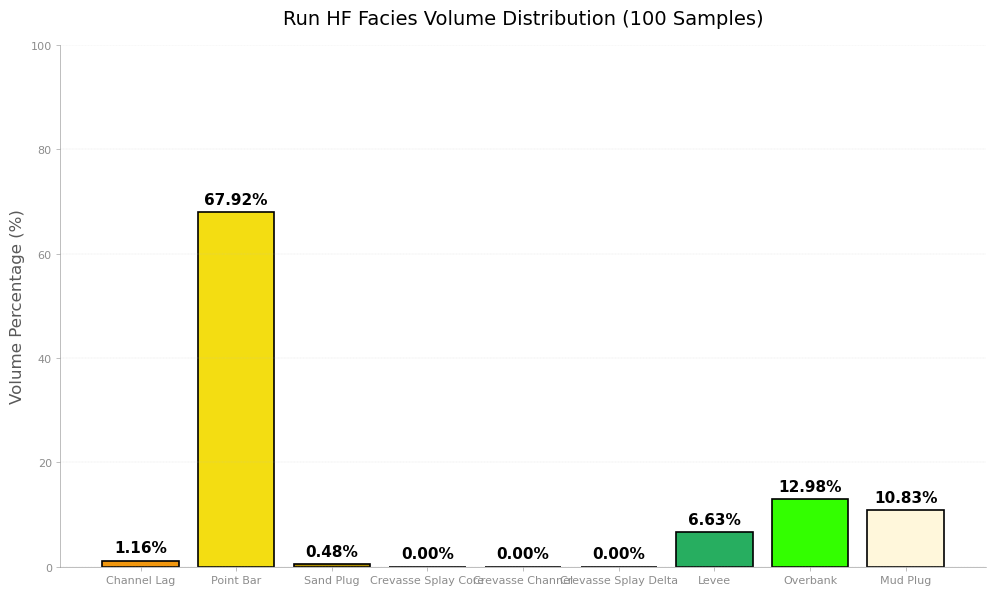


--- Generating 3D PyVista Entropy Map (Run HF) ---


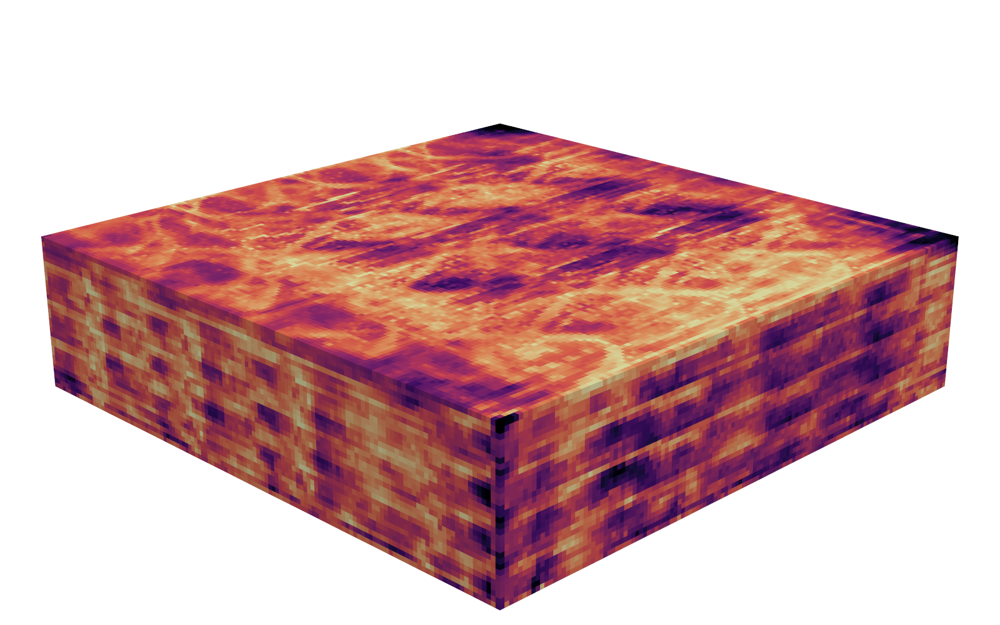

Saved 3D Entropy Map to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\3d_plot_gan_ensemble_entropy.png


In [ ]:
output_dir_HF = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
gan_data_dir_HF = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\realizations\*.npy"
gan_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"

validator_hf = PostProcessing(flumy_name='setting 2', gan_name='Run HF', gan_description='High Fidelity Model',
                              output_dir=output_dir_HF, data_path=data_dir_2, gan_path=gan_data_dir_HF, num_classes=9)

validator_hf.load_flumy_samples()
validator_hf.load_gan_samples()
validator_hf.plot_facies_percentages()
validator_hf.plot_3d_entropy_pyvista()

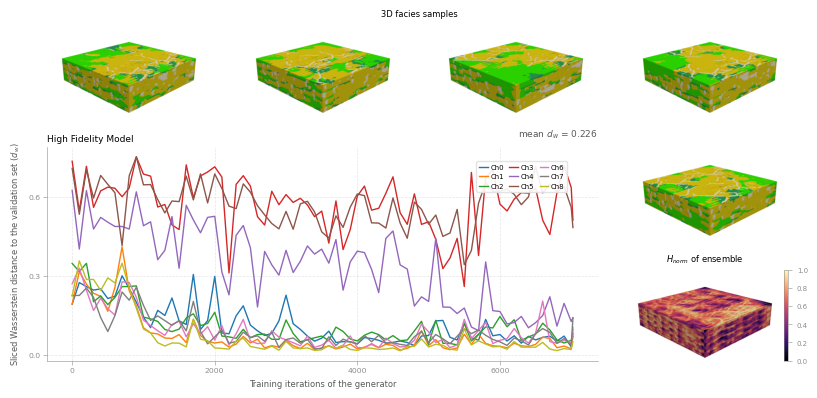

In [ ]:
# validator_fac1.plot_entropy(data_source='real', axis='Z', num_slices=1, plot_title=False, show_plot=False, save_plot=True)
# validator_fac1.plot_3d_pyvista(data_source='real', mode= 'combined', show_legend=False, show_plot=False, save_plot=True)

# validator_fac2.plot_entropy(data_source='real', axis='Z', num_slices=1, plot_title=False, show_plot=False, save_plot=True)
# validator_fac2.plot_3d_pyvista(data_source='real', mode= 'combined', show_legend=False, show_plot=False, save_plot=True)

# validator_fac3.plot_entropy(data_source= 'real',axis='Z', num_slices=1, plot_title=False, show_plot=False, save_plot=True)
# validator_fac3.plot_3d_pyvista(data_source='real',mode= 'combined', show_legend=False, show_plot=False, save_plot=True)

# print("Started loading in images")
# out_dir_1 = validator_fac1.output_dir
# out_dir_2 = validator_fac2.output_dir
# out_dir_3 = validator_fac3.output_dir

# entropy_img_1 = max(glob.glob(os.path.join(out_dir_1, 'norm_entropy_real_XY_*_samples_*_slices.png')), key=os.path.getctime)
# pyvista_img_1 = max(glob.glob(os.path.join(out_dir_1, '3d_plot_real_sample_*.png')), key=os.path.getctime)
# entropy_img_2 = max(glob.glob(os.path.join(out_dir_2, 'norm_entropy_real_XY_*_samples_*_slices.png')), key=os.path.getctime)
# pyvista_img_2 = max(glob.glob(os.path.join(out_dir_2, '3d_plot_real_sample_*.png')), key=os.path.getctime)
# entropy_img_3 = max(glob.glob(os.path.join(out_dir_3, 'norm_entropy_real_XY_*_samples_*_slices.png')), key=os.path.getctime)
# pyvista_img_3 = max(glob.glob(os.path.join(out_dir_3, '3d_plot_real_sample_*.png')), key=os.path.getctime)

# img_ent1 = mpimg.imread(entropy_img_1)
# img_pv1 = mpimg.imread(pyvista_img_1)
# img_ent2 =mpimg.imread(entropy_img_2)
# img_pv2 = mpimg.imread(pyvista_img_2)
# img_ent3 =mpimg.imread(entropy_img_3)
# img_pv3 = mpimg.imread(pyvista_img_3)
# print("Finished loading in images\n")

# print("Started creating plot")
# fig, axes = plt.subplots(3, 2, figsize=(8.27, 11.69))

# # --- ROW 1 ---
# # First column (with title)
# axes[0,0].set_title("a) Setting 1", fontsize=16, fontweight='bold', loc="left")
# axes[0,0].imshow(img_pv2)
# axes[0,0].axis('off') # Hide axes for images
# # Second column
# axes[0,1].imshow(img_ent2)
# axes[0,1].axis('off')

# # --- ROW 2 ---
# # First column (with title)
# axes[1,0].set_title("b) Setting 2", fontsize=16, fontweight='bold', loc="left")
# axes[1,0].imshow(img_pv1)
# axes[1,0].axis('off') 
# # Second column
# axes[1,1].imshow(img_ent1)
# axes[1,1].axis('off')

# # --- ROW 3 ---
# # First column (with title)
# axes[2,0].set_title("c) Setting 3", fontsize=16, fontweight='bold', loc="left")
# axes[2,0].imshow(img_pv3)
# axes[2,0].axis('off') 
# # Second column
# axes[2,1].imshow(img_ent3)
# axes[2,1].axis('off')

# plt.tight_layout()
# plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# 1. Generate and save the individual plots silently
# (They will print the file paths they save to)
# validator.plot_facies_percentages(mode='both', show_plot=False, save_plot=True)
# validator.plot_entropy(axis='Z', num_slices=3, show_plot=False, save_plot=True)
# validator.plot_3d_pyvista(mode= 'combined',show_plot=False, save_plot=True)

# 2. Find the newly generated files
print("Started loading in images")
out_dir = validator.output_dir
facies_img = max(glob.glob(os.path.join(out_dir, 'facies_distribution_both*.png')), key=os.path.getctime)
entropy_img = max(glob.glob(os.path.join(out_dir, 'entropy_XY_*_3_slices.png')), key=os.path.getctime)
pyvista_img = max(glob.glob(os.path.join(out_dir, '3d_plot_sample_*.png')), key=os.path.getctime)

# 3. Read the images
img1 = mpimg.imread(facies_img)
img2 = mpimg.imread(entropy_img)
img3 = mpimg.imread(pyvista_img)
print("Finished loading in images\n")

# 4. Stitch them together in a 3-row plot
print("Started creating plot")
fig, axes = plt.subplots(3, 1, figsize=(8.27, 11.69))

axes[0].imshow(img1)
axes[0].axis('off') # Hide axes for images

axes[1].imshow(img2)
axes[1].axis('off')

axes[2].imshow(img3)
axes[2].axis('off')

plt.tight_layout()
plt.show()